# Electricity Load Analytics
## Day of Year Analysis and Residual Modeling

Similar to temperature analytics, we model electricity load patterns:
- Seasonal patterns (day of year)
- Trend fitting
- Residual analysis

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.stats import genextreme, genpareto, pareto
from scipy.optimize import minimize

from wxderivs import SET_TARGET_US_CITIES, MONTH_CDD, MONTH_HDD, DIR_WORK

# Import seasonal modeling functions
from seasonal_models import (
    fit_seasonal_model,
    fit_seasonal_garch_model,
    compare_models,
    fit_all_regions,
    plot_model_comparison,
    plot_aic_bic_comparison,
    # Diagnostic functions
    plot_fitted_model_and_residuals,
    plot_residual_distribution,
    plot_autocorrelation,
    analyze_volatility_clustering,
    run_full_diagnostics
)

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

sys.path.append(str(DIR_WORK / "unibm"))

import unibm
import unibm.benchmark


0 /workspaces/Financial-Engineering-Project/notebooks/wxderivs/../../data/raw/temperature/Essen.csv
1 /workspaces/Financial-Engineering-Project/notebooks/wxderivs/../../data/raw/temperature/Boston.csv
2 /workspaces/Financial-Engineering-Project/notebooks/wxderivs/../../data/raw/temperature/Philadelphia.csv
3 /workspaces/Financial-Engineering-Project/notebooks/wxderivs/../../data/raw/temperature/NewYork.csv
4 /workspaces/Financial-Engineering-Project/notebooks/wxderivs/../../data/raw/temperature/Burbank.csv
5 /workspaces/Financial-Engineering-Project/notebooks/wxderivs/../../data/raw/temperature/London.csv
6 /workspaces/Financial-Engineering-Project/notebooks/wxderivs/../../data/raw/temperature/Dallas.csv
7 /workspaces/Financial-Engineering-Project/notebooks/wxderivs/../../data/raw/temperature/Paris.csv
8 /workspaces/Financial-Engineering-Project/notebooks/wxderivs/../../data/raw/temperature/Portland.csv
9 /workspaces/Financial-Engineering-Project/notebooks/wxderivs/../../data/raw/tempe

In [2]:
# Reload the seasonal_models module to get the latest changes
import importlib
import seasonal_models
importlib.reload(seasonal_models)

# Re-import the functions after reload
from seasonal_models import (
    fit_seasonal_model,
    fit_seasonal_garch_model,
    compare_models,
    fit_all_regions,
    plot_model_comparison,
    plot_aic_bic_comparison,
    # Diagnostic functions
    plot_fitted_model_and_residuals,
    plot_residual_distribution,
    plot_autocorrelation,
    analyze_volatility_clustering,
    run_full_diagnostics
)

print("✓ seasonal_models module reloaded successfully!")

✓ seasonal_models module reloaded successfully!


## Load Data

Load processed electricity data from multiple regions

In [3]:
# Load Boston data (aligned columns: date, pred_min, pred_max, pred_avg, min_load, max_load, avg_load)
df_boston = pd.read_csv('../data/processed/Boston/Boston.csv')
df_boston['date'] = pd.to_datetime(df_boston['date'])
# df_boston = df_boston[pd.to_datetime(df_boston['date']).dt.dayofweek < 5]
df_boston = df_boston[(df_boston['date'] >= '2014-01-01') & (df_boston['date'] <= '2022-12-31')]
df_boston.set_index('date', inplace=True)

# Load other region data (aligned columns: date, min_load, max_load, avg_load)
df_ny = pd.read_csv('../data/processed/NY/NewYork.csv')

df_ny['date'] = pd.to_datetime(df_ny['date'])
# Remove weekends (Saturday=5, Sunday=6)
# df_ny = df_ny[pd.to_datetime(df_ny['date']).dt.dayofweek < 5]
df_ny = df_ny[(df_ny['date'] >= '2014-01-01') & (df_ny['date'] <= '2022-12-31')]
df_ny.set_index('date', inplace=True)

# df_houston = pd.read_csv('../data/processed/Houston/Houston.csv')
# df_houston =  df_houston[pd.to_datetime(df_houston['date']).dt.dayofweek < 5]
# df_houston['date'] = pd.to_datetime(df_houston['date'])
# df_houston = df_houston[(df_houston['date'] >= '2014-01-01') & (df_houston['date'] <= '2022-12-31')]
# df_houston.set_index('date', inplace=True)

df_chicago = pd.read_csv('../data/processed/Chicago/Chicago.csv')
df_chicago['date'] = pd.to_datetime(df_chicago['date'])
# df_chicago = df_chicago[pd.to_datetime(df_chicago['date']).dt.dayofweek < 5]
df_chicago = df_chicago[(df_chicago['date'] <= '2022-12-31') & (df_chicago['date'] >= '2014-01-01')]
df_chicago.set_index('date', inplace=True)

# df_dallas = pd.read_csv('../data/processed/Dallas/Dallas.csv')
# df_dallas['date'] = pd.to_datetime(df_dallas['date'])
# df_dallas = df_dallas[pd.to_datetime(df_dallas['date']).dt.dayofweek < 5]
# df_dallas = df_dallas[(df_dallas['date'] >= '2014-01-01') & (df_dallas['date'] <= '2022-12-31')]
# df_dallas.set_index('date', inplace=True)

df_minneapolis = pd.read_csv('../data/processed/Minneapolis/Minneapolis.csv')
df_minneapolis['date'] = pd.to_datetime(df_minneapolis['date'])
# df_minneapolis = df_minneapolis[pd.to_datetime(df_minneapolis['date']).dt.dayofweek < 5]
df_minneapolis = df_minneapolis[(df_minneapolis['date'] >= '2014-01-01') & (df_minneapolis['date'] <= '2022-12-31')]
df_minneapolis.set_index('date', inplace=True)

print("Boston data shape:", df_boston.shape)
print("New York data shape:", df_ny.shape)
print("Chicago data shape:", df_chicago.shape)
print("Minneapolis data shape:", df_minneapolis.shape)
print("\nBoston columns:", df_boston.columns.tolist())
print("\nBoston data range:", df_boston.index.min(), "to", df_boston.index.max())

Boston data shape: (3287, 6)
New York data shape: (3287, 3)
Chicago data shape: (3286, 3)
Minneapolis data shape: (3287, 3)

Boston columns: ['pred_min', 'pred_max', 'pred_avg', 'min_load', 'max_load', 'avg_load']

Boston data range: 2014-01-01 00:00:00 to 2022-12-31 00:00:00


In [4]:
# Preview data
df_boston.head(10)

,pred_min,pred_max,pred_avg,min_load,max_load,avg_load
date,,,,,,
2014-01-01,2493.1,3649.9,3071.50,2574.0,3549.0,3061.5
2014-01-02,2499.2,3852.0,3175.60,2554.0,4109.0,3331.5
2014-01-03,2627.6,3905.0,3266.30,2942.0,4138.0,3540.0
2014-01-04,2682.0,3506.9,3094.45,2976.0,3712.0,3344.0
2014-01-05,2289.1,3163.3,2726.20,2622.0,3518.0,3070.0
2014-01-06,2187.6,3442.0,2814.80,2342.0,3545.0,2943.5
2014-01-07,2444.2,3841.8,3143.00,2471.0,4101.0,3286.0
2014-01-08,2637.5,3888.5,3263.00,2928.0,4036.0,3482.0
2014-01-09,2593.3,3784.7,3189.00,2764.0,3851.0,3307.5


## Plotting Functions

Define functions to plot day-of-year patterns and residuals

In [5]:
def plot_day_of_year(
    srs,
    is_day_of_year_frac=False,
    is_scatter=False,
    alpha=0.7,
    is_label=False,
    xlabel="Day of year",
    ylabel="Load (MWh)",
    title="Load vs Day of year",
    axhline=None,
    axvline_red=None,
    axvline_blue=None,
    ax=None,
):
    """Plot time series against day of year, colored by year."""
    if is_day_of_year_frac:
        vec_t = (srs.index.day_of_year / (srs.index.is_leap_year + 365)).to_numpy()
    else:
        vec_t = srs.index.day_of_year.to_numpy()
    vec_y = srs.to_numpy()
    year_unique = srs.index.year.unique()
    cmap = plt.get_cmap("rainbow", len(year_unique))
    color_map = {year: cmap(i) for i, year in enumerate(year_unique)}
    if ax is None:
        fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 6))
    for year in year_unique:
        idx = srs.index.year == year
        if is_scatter:
            ax.scatter(
                vec_t[idx],
                vec_y[idx],
                s=3,
                color=color_map[year],
                alpha=alpha,
                label=year if is_label else None,
            )
        else:
            ax.plot(
                vec_t[idx],
                vec_y[idx],
                label=year if is_label else None,
                alpha=alpha,
                lw=1.5,
                c=color_map[year],
                linestyle="-",
            )
    if axhline:
        for val in axhline:
            ax.axhline(val, color="black", linestyle="--", lw=0.9)
    if axvline_red:
        for val in axvline_red:
            ax.axvline(val, color="red", linestyle="--", lw=0.9)
    if axvline_blue:
        for val in axvline_blue:
            ax.axvline(val, color="blue", linestyle="--", lw=0.9)
    ax.grid(True, alpha=0.3)
    if is_label:
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    return ax

## Day of Year Patterns

Visualize how electricity load varies by day of year across multiple years

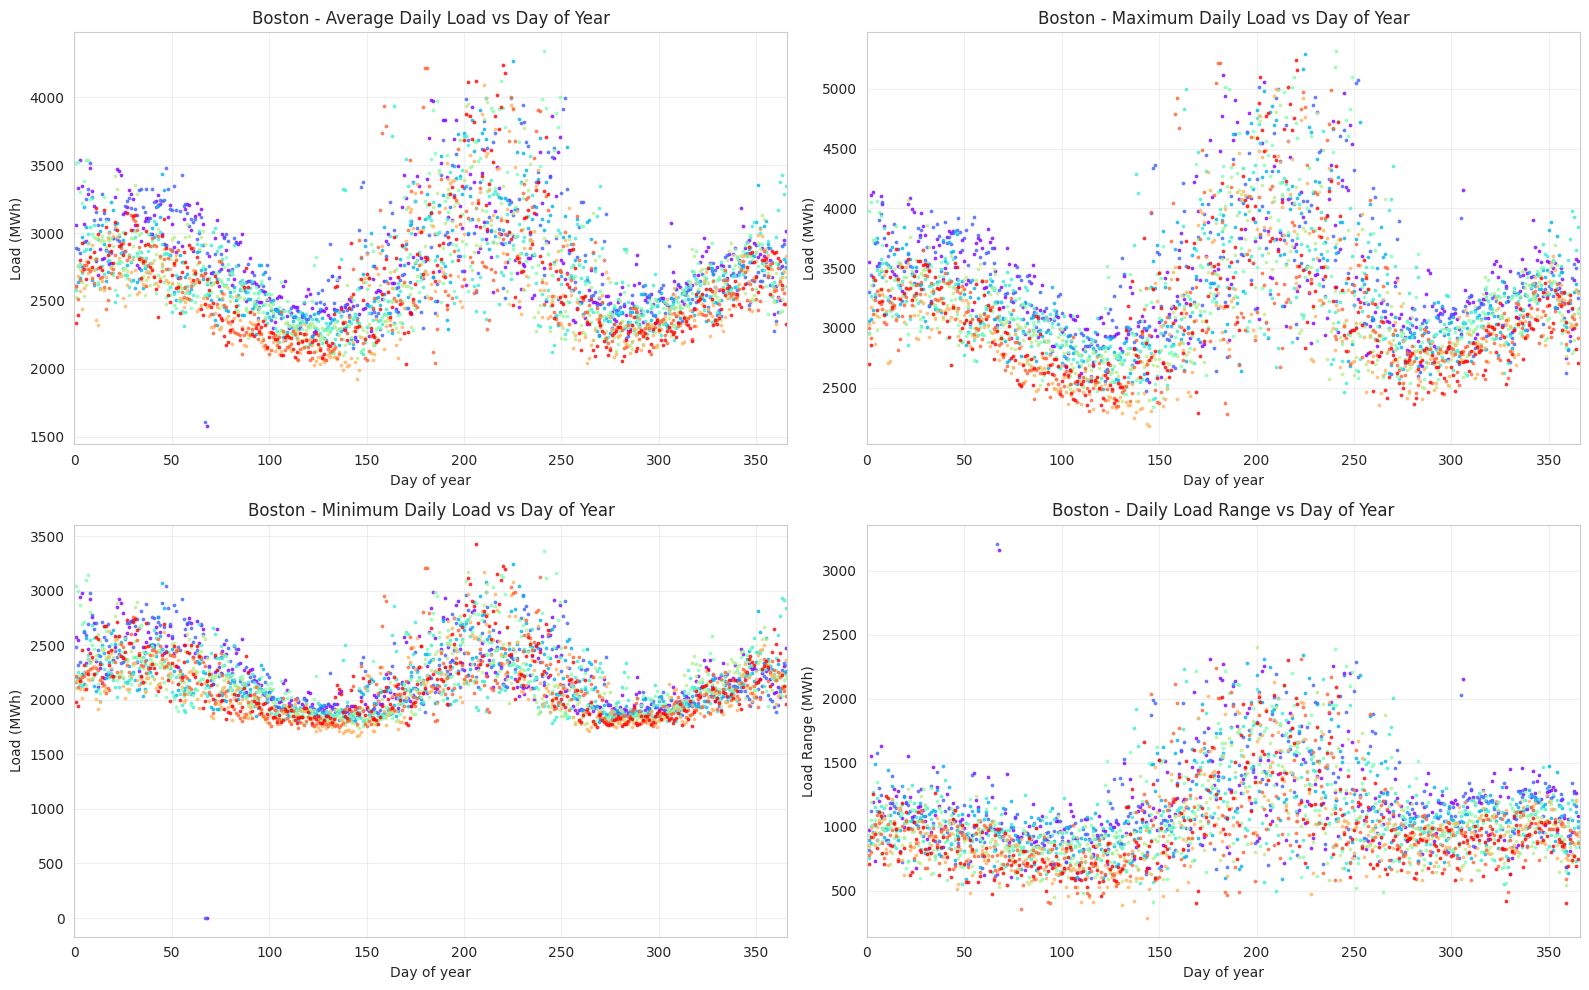

In [6]:
# Plot actual load for Boston
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 10))

plot_day_of_year(
    df_boston['avg_load'],
    is_scatter=True,
    title="Boston - Average Daily Load vs Day of Year",
    ylabel="Load (MWh)",
    ax=axes[0, 0],
)

plot_day_of_year(
    df_boston['max_load'],
    is_scatter=True,
    title="Boston - Maximum Daily Load vs Day of Year",
    ylabel="Load (MWh)",
    ax=axes[0, 1],
)

plot_day_of_year(
    df_boston['min_load'],
    is_scatter=True,
    title="Boston - Minimum Daily Load vs Day of Year",
    ylabel="Load (MWh)",
    ax=axes[1, 0],
)

# Plot load range (max - min)
load_range = df_boston['max_load'] - df_boston['min_load']
plot_day_of_year(
    load_range,
    is_scatter=True,
    title="Boston - Daily Load Range vs Day of Year",
    ylabel="Load Range (MWh)",
    ax=axes[1, 1],
)

for ax in axes.flatten():
    ax.set_xlim(0, 366)

plt.tight_layout()
plt.savefig('../data/processed/Boston/day_of_year_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

## Day of Year Patterns - New York

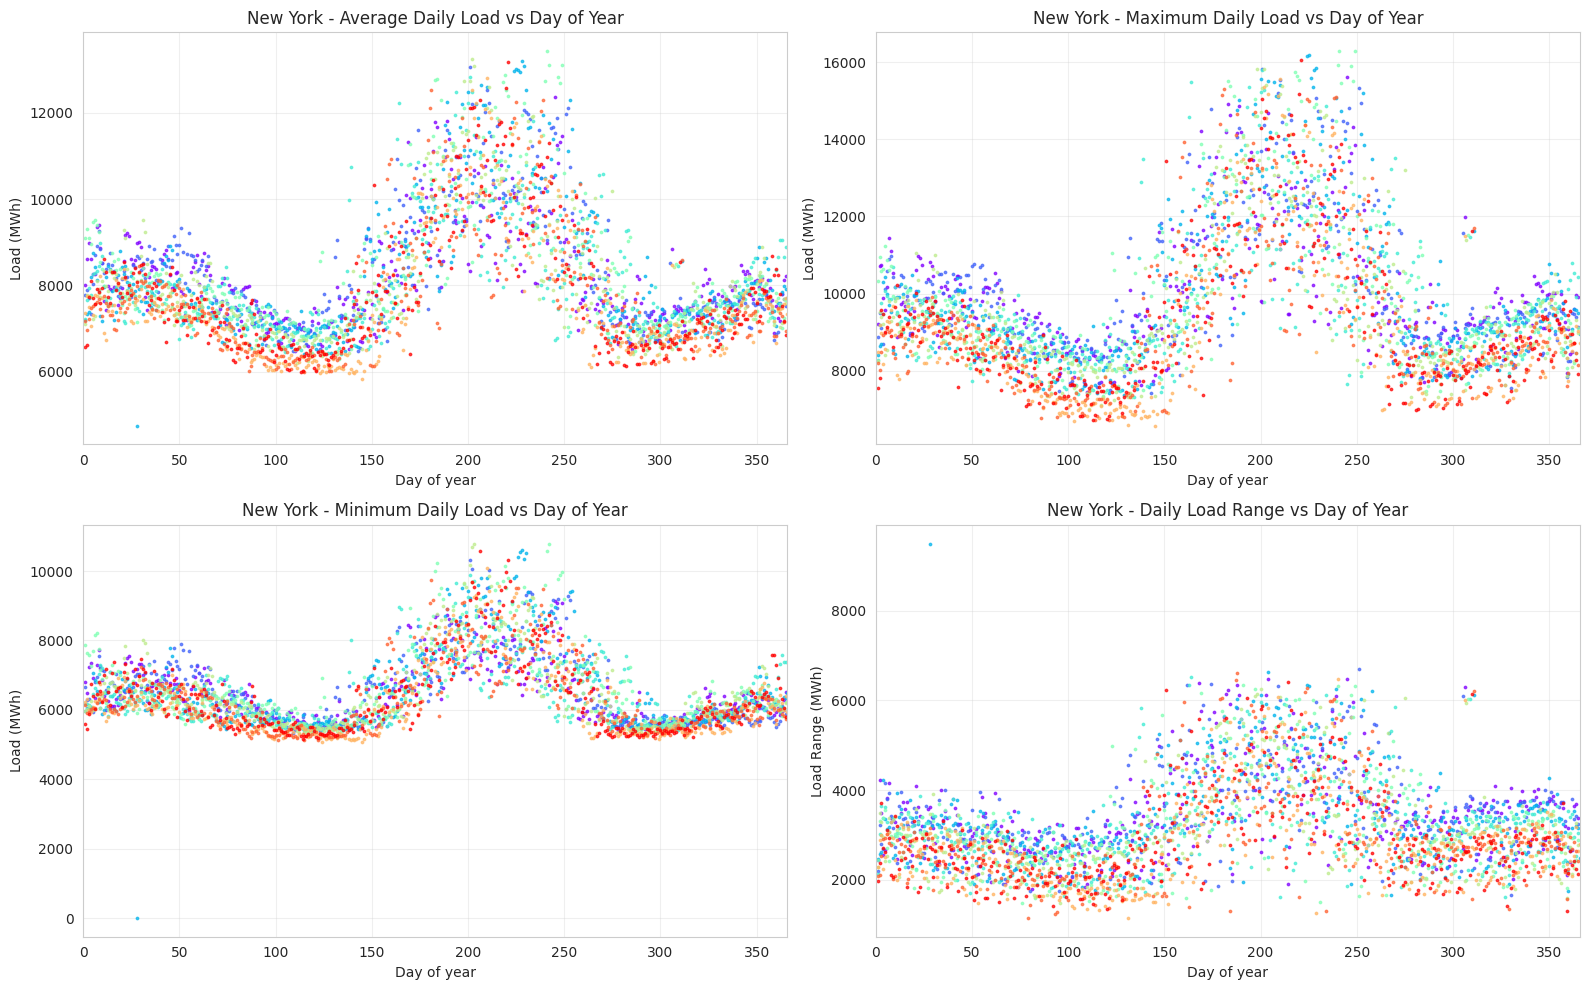

In [7]:
# Plot actual load for New York
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 10))

plot_day_of_year(
    df_ny['avg_load'],
    is_scatter=True,
    title="New York - Average Daily Load vs Day of Year",
    ylabel="Load (MWh)",
    ax=axes[0, 0],
)

plot_day_of_year(
    df_ny['max_load'],
    is_scatter=True,
    title="New York - Maximum Daily Load vs Day of Year",
    ylabel="Load (MWh)",
    ax=axes[0, 1],
)

plot_day_of_year(
    df_ny['min_load'],
    is_scatter=True,
    title="New York - Minimum Daily Load vs Day of Year",
    ylabel="Load (MWh)",
    ax=axes[1, 0],
)

# Plot load range (max - min)
load_range_ny = df_ny['max_load'] - df_ny['min_load']
plot_day_of_year(
    load_range_ny,
    is_scatter=True,
    title="New York - Daily Load Range vs Day of Year",
    ylabel="Load Range (MWh)",
    ax=axes[1, 1],
)

for ax in axes.flatten():
    ax.set_xlim(0, 366)

plt.tight_layout()
plt.savefig('../data/processed/NY/day_of_year_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

## Day of Year Patterns - Houston

In [8]:
# # Plot actual load for Houston
# fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 10))

# plot_day_of_year(
#     df_houston['avg_load'],
#     is_scatter=True,
#     title="Houston - Average Daily Load vs Day of Year",
#     ylabel="Load (MWh)",
#     ax=axes[0, 0],
# )

# plot_day_of_year(
#     df_houston['max_load'],
#     is_scatter=True,
#     title="Houston - Maximum Daily Load vs Day of Year",
#     ylabel="Load (MWh)",
#     ax=axes[0, 1],
# )

# plot_day_of_year(
#     df_houston['min_load'],
#     is_scatter=True,
#     title="Houston - Minimum Daily Load vs Day of Year",
#     ylabel="Load (MWh)",
#     ax=axes[1, 0],
# )

# # Plot load range (max - min)
# load_range_houston = df_houston['max_load'] - df_houston['min_load']
# plot_day_of_year(
#     load_range_houston,
#     is_scatter=True,
#     title="Houston - Daily Load Range vs Day of Year",
#     ylabel="Load Range (MWh)",
#     ax=axes[1, 1],
# )

# for ax in axes.flatten():
#     ax.set_xlim(0, 366)

# plt.tight_layout()
# plt.savefig('../data/processed/Houston/day_of_year_patterns.png', dpi=150, bbox_inches='tight')
# plt.show()

## Day of Year Patterns - Chicago

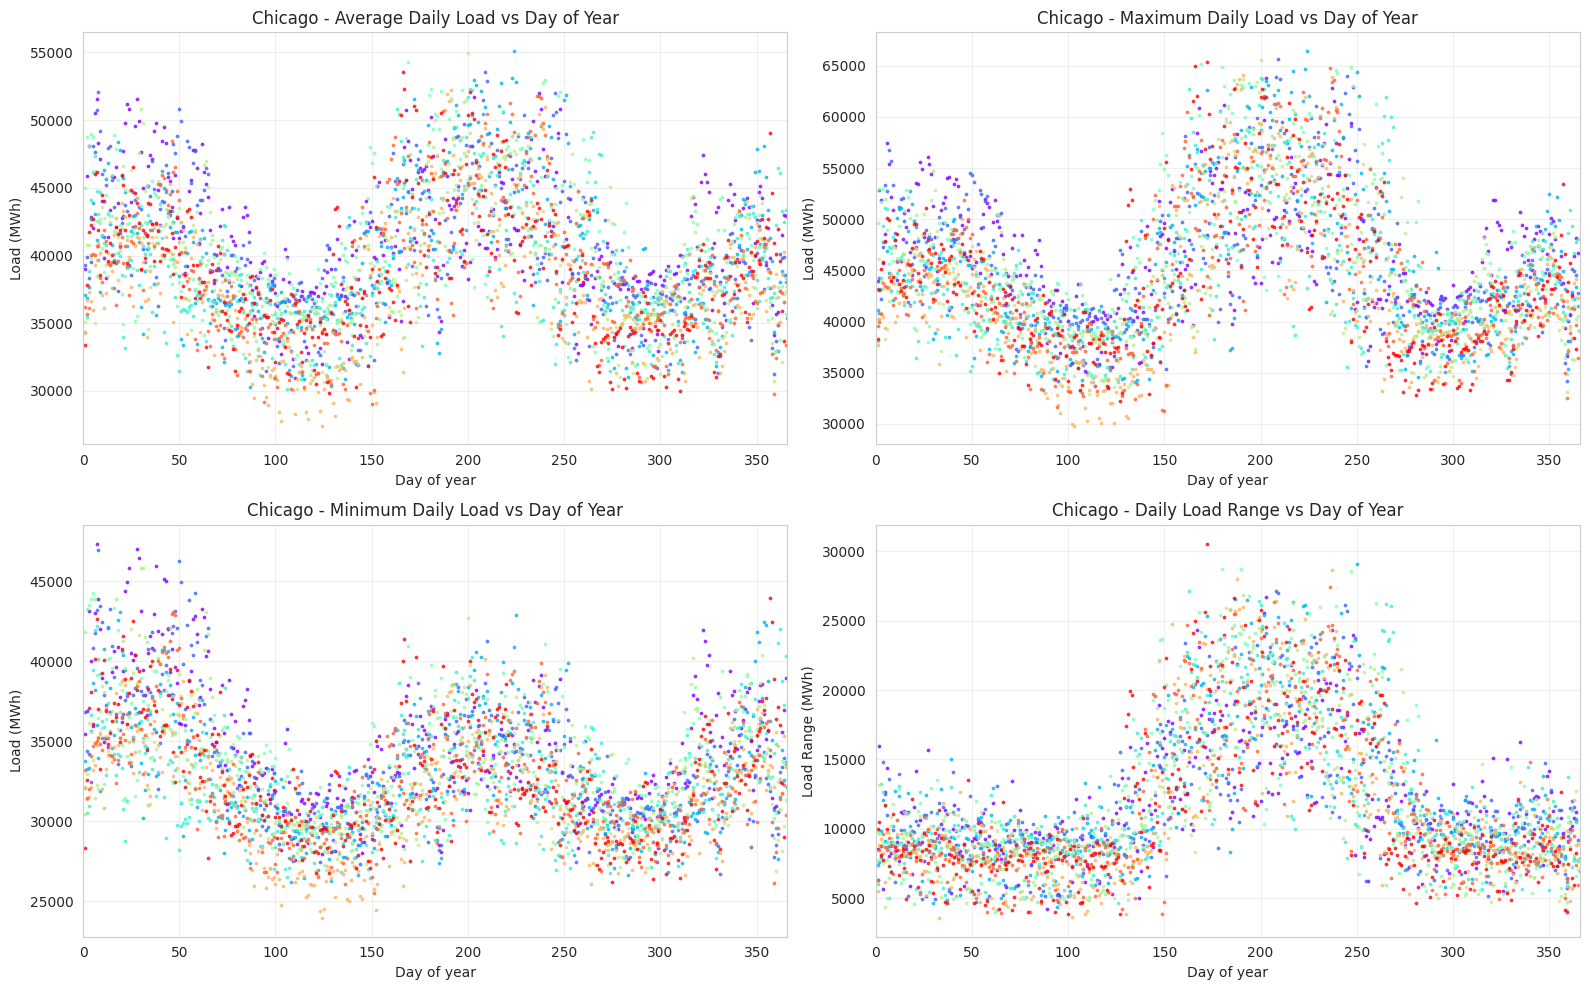

In [9]:
# Plot actual load for Chicago
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 10))

plot_day_of_year(
    df_chicago['avg_load'],
    is_scatter=True,
    title="Chicago - Average Daily Load vs Day of Year",
    ylabel="Load (MWh)",
    ax=axes[0, 0],
)

plot_day_of_year(
    df_chicago['max_load'],
    is_scatter=True,
    title="Chicago - Maximum Daily Load vs Day of Year",
    ylabel="Load (MWh)",
    ax=axes[0, 1],
)

plot_day_of_year(
    df_chicago['min_load'],
    is_scatter=True,
    title="Chicago - Minimum Daily Load vs Day of Year",
    ylabel="Load (MWh)",
    ax=axes[1, 0],
)

# Plot load range (max - min)
load_range_chicago = df_chicago['max_load'] - df_chicago['min_load']
plot_day_of_year(
    load_range_chicago,
    is_scatter=True,
    title="Chicago - Daily Load Range vs Day of Year",
    ylabel="Load Range (MWh)",
    ax=axes[1, 1],
)

for ax in axes.flatten():
    ax.set_xlim(0, 366)

plt.tight_layout()
plt.savefig('../data/processed/Chicago/day_of_year_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

## Day of Year Patterns - Dallas

In [10]:
# # Plot actual load for Dallas
# fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 10))

# plot_day_of_year(
#     df_dallas['avg_load'],
#     is_scatter=True,
#     title="Dallas - Average Daily Load vs Day of Year",
#     ylabel="Load (MWh)",
#     ax=axes[0, 0],
# )

# plot_day_of_year(
#     df_dallas['max_load'],
#     is_scatter=True,
#     title="Dallas - Maximum Daily Load vs Day of Year",
#     ylabel="Load (MWh)",
#     ax=axes[0, 1],
# )

# plot_day_of_year(
#     df_dallas['min_load'],
#     is_scatter=True,
#     title="Dallas - Minimum Daily Load vs Day of Year",
#     ylabel="Load (MWh)",
#     ax=axes[1, 0],
# )

# # Plot load range (max - min)
# load_range_dallas = df_dallas['max_load'] - df_dallas['min_load']
# plot_day_of_year(
#     load_range_dallas,
#     is_scatter=True,
#     title="Dallas - Daily Load Range vs Day of Year",
#     ylabel="Load Range (MWh)",
#     ax=axes[1, 1],
# )

# for ax in axes.flatten():
#     ax.set_xlim(0, 366)

# plt.tight_layout()
# plt.savefig('../data/processed/Dallas/day_of_year_patterns.png', dpi=150, bbox_inches='tight')
# plt.show()

## Day of Year Patterns - Minneapolis

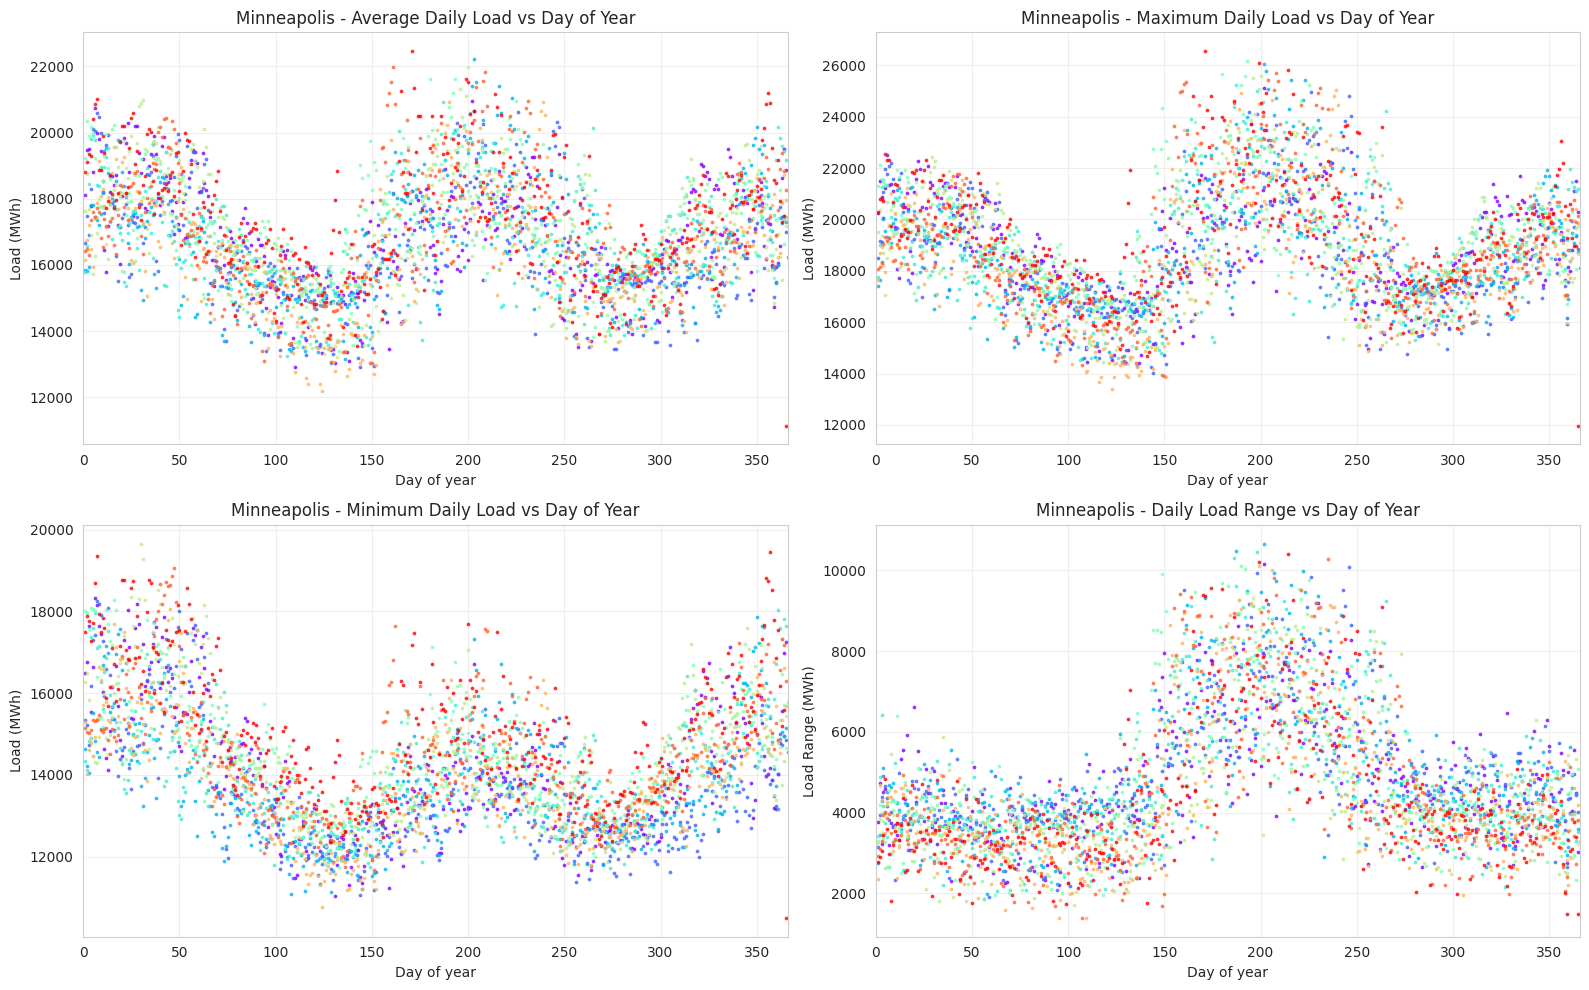

In [11]:
# Plot actual load for Minneapolis
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 10))

plot_day_of_year(
    df_minneapolis['avg_load'],
    is_scatter=True,
    title="Minneapolis - Average Daily Load vs Day of Year",
    ylabel="Load (MWh)",
    ax=axes[0, 0],
)

plot_day_of_year(
    df_minneapolis['max_load'],
    is_scatter=True,
    title="Minneapolis - Maximum Daily Load vs Day of Year",
    ylabel="Load (MWh)",
    ax=axes[0, 1],
)

plot_day_of_year(
    df_minneapolis['min_load'],
    is_scatter=True,
    title="Minneapolis - Minimum Daily Load vs Day of Year",
    ylabel="Load (MWh)",
    ax=axes[1, 0],
)

# Plot load range (max - min)
load_range_minneapolis = df_minneapolis['max_load'] - df_minneapolis['min_load']
plot_day_of_year(
    load_range_minneapolis,
    is_scatter=True,
    title="Minneapolis - Daily Load Range vs Day of Year",
    ylabel="Load Range (MWh)",
    ax=axes[1, 1],
)

for ax in axes.flatten():
    ax.set_xlim(0, 366)

plt.tight_layout()
plt.savefig('../data/processed/Minneapolis/day_of_year_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

## All Regions Comparison - Day of Year Patterns

Side-by-side comparison of average load patterns for all regions

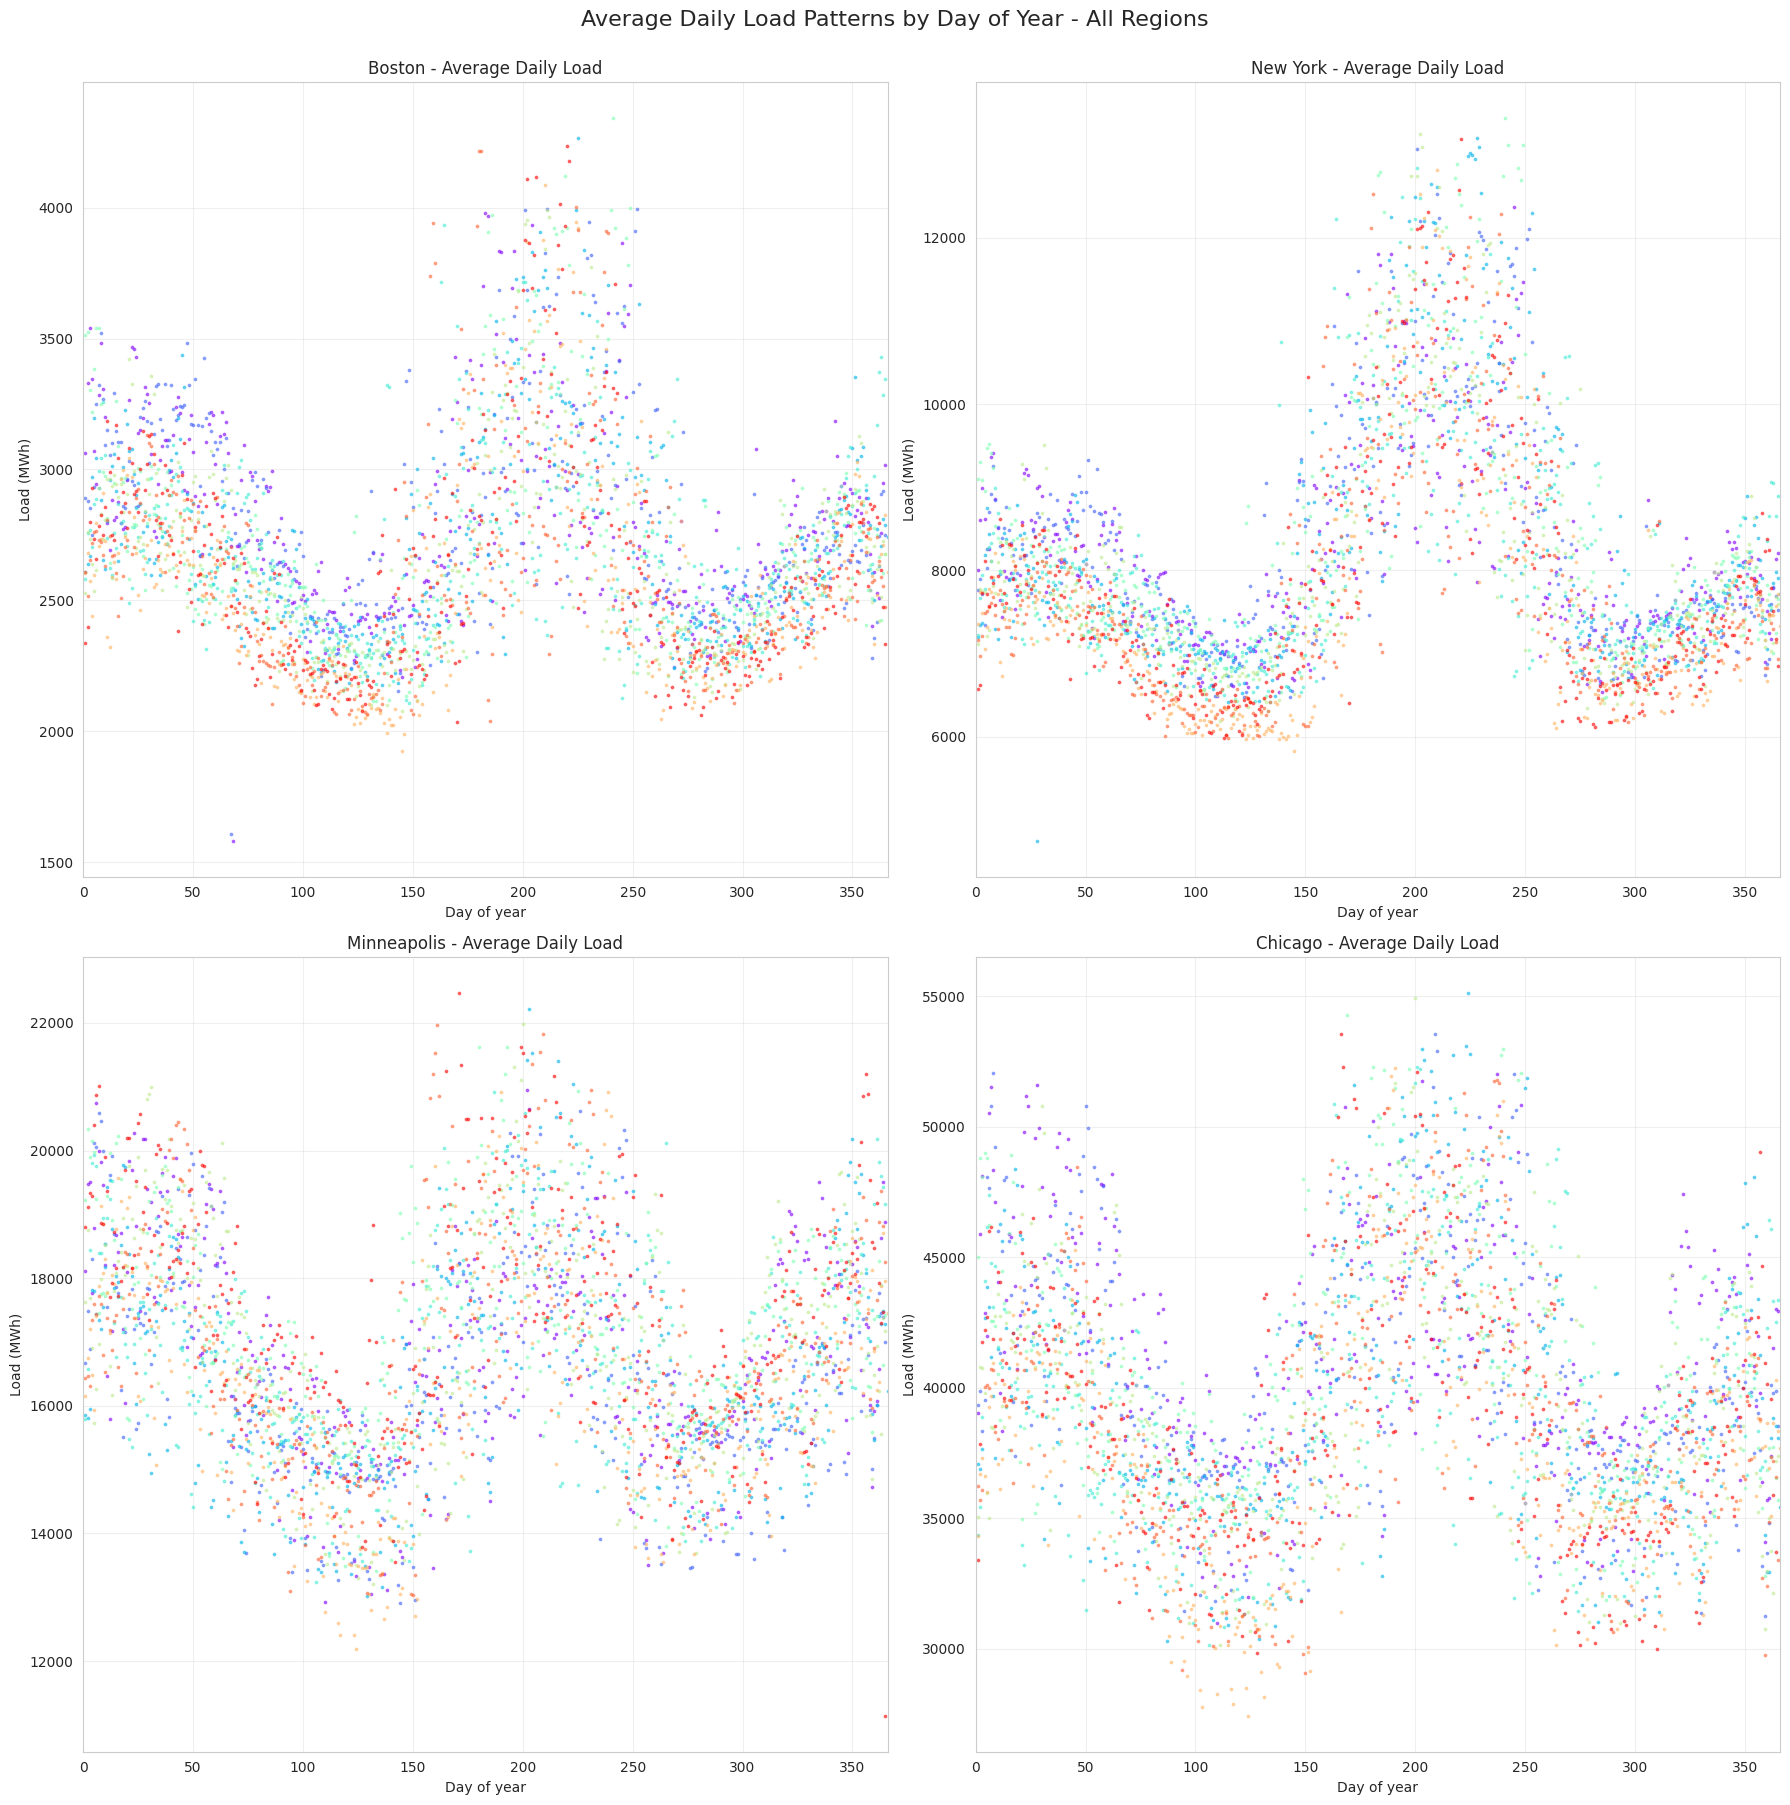

In [12]:
# Create a 3x2 grid comparing all 6 regions
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 18))

# Boston
plot_day_of_year(
    df_boston['avg_load'],
    is_scatter=True,
    title="Boston - Average Daily Load",
    ylabel="Load (MWh)",
    alpha=0.5,
    ax=axes[0, 0],
)

# New York
plot_day_of_year(
    df_ny['avg_load'],
    is_scatter=True,
    title="New York - Average Daily Load",
    ylabel="Load (MWh)",
    alpha=0.5,
    ax=axes[0, 1],
)

# Houston
# plot_day_of_year(
#     df_houston['avg_load'],
#     is_scatter=True,
#     title="Houston - Average Daily Load",
#     ylabel="Load (MWh)",
#     alpha=0.5,
#     ax=axes[1, 0],
# )

# Chicago
plot_day_of_year(
    df_chicago['avg_load'],
    is_scatter=True,
    title="Chicago - Average Daily Load",
    ylabel="Load (MWh)",
    alpha=0.5,
    ax=axes[1, 1],
)

# Dallas
# plot_day_of_year(
#     df_dallas['avg_load'],
#     is_scatter=True,
#     title="Dallas - Average Daily Load",
#     ylabel="Load (MWh)",
#     alpha=0.5,
#     ax=axes[2, 0],
# )

# Minneapolis
plot_day_of_year(
    df_minneapolis['avg_load'],
    is_scatter=True,
    title="Minneapolis - Average Daily Load",
    ylabel="Load (MWh)",
    alpha=0.5,
    ax=axes[1, 0],
)

for ax in axes.flatten():
    ax.set_xlim(0, 366)

plt.suptitle('Average Daily Load Patterns by Day of Year - All Regions', fontsize=16, y=1.00)
plt.tight_layout()
plt.savefig('../data/processed/all_regions_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

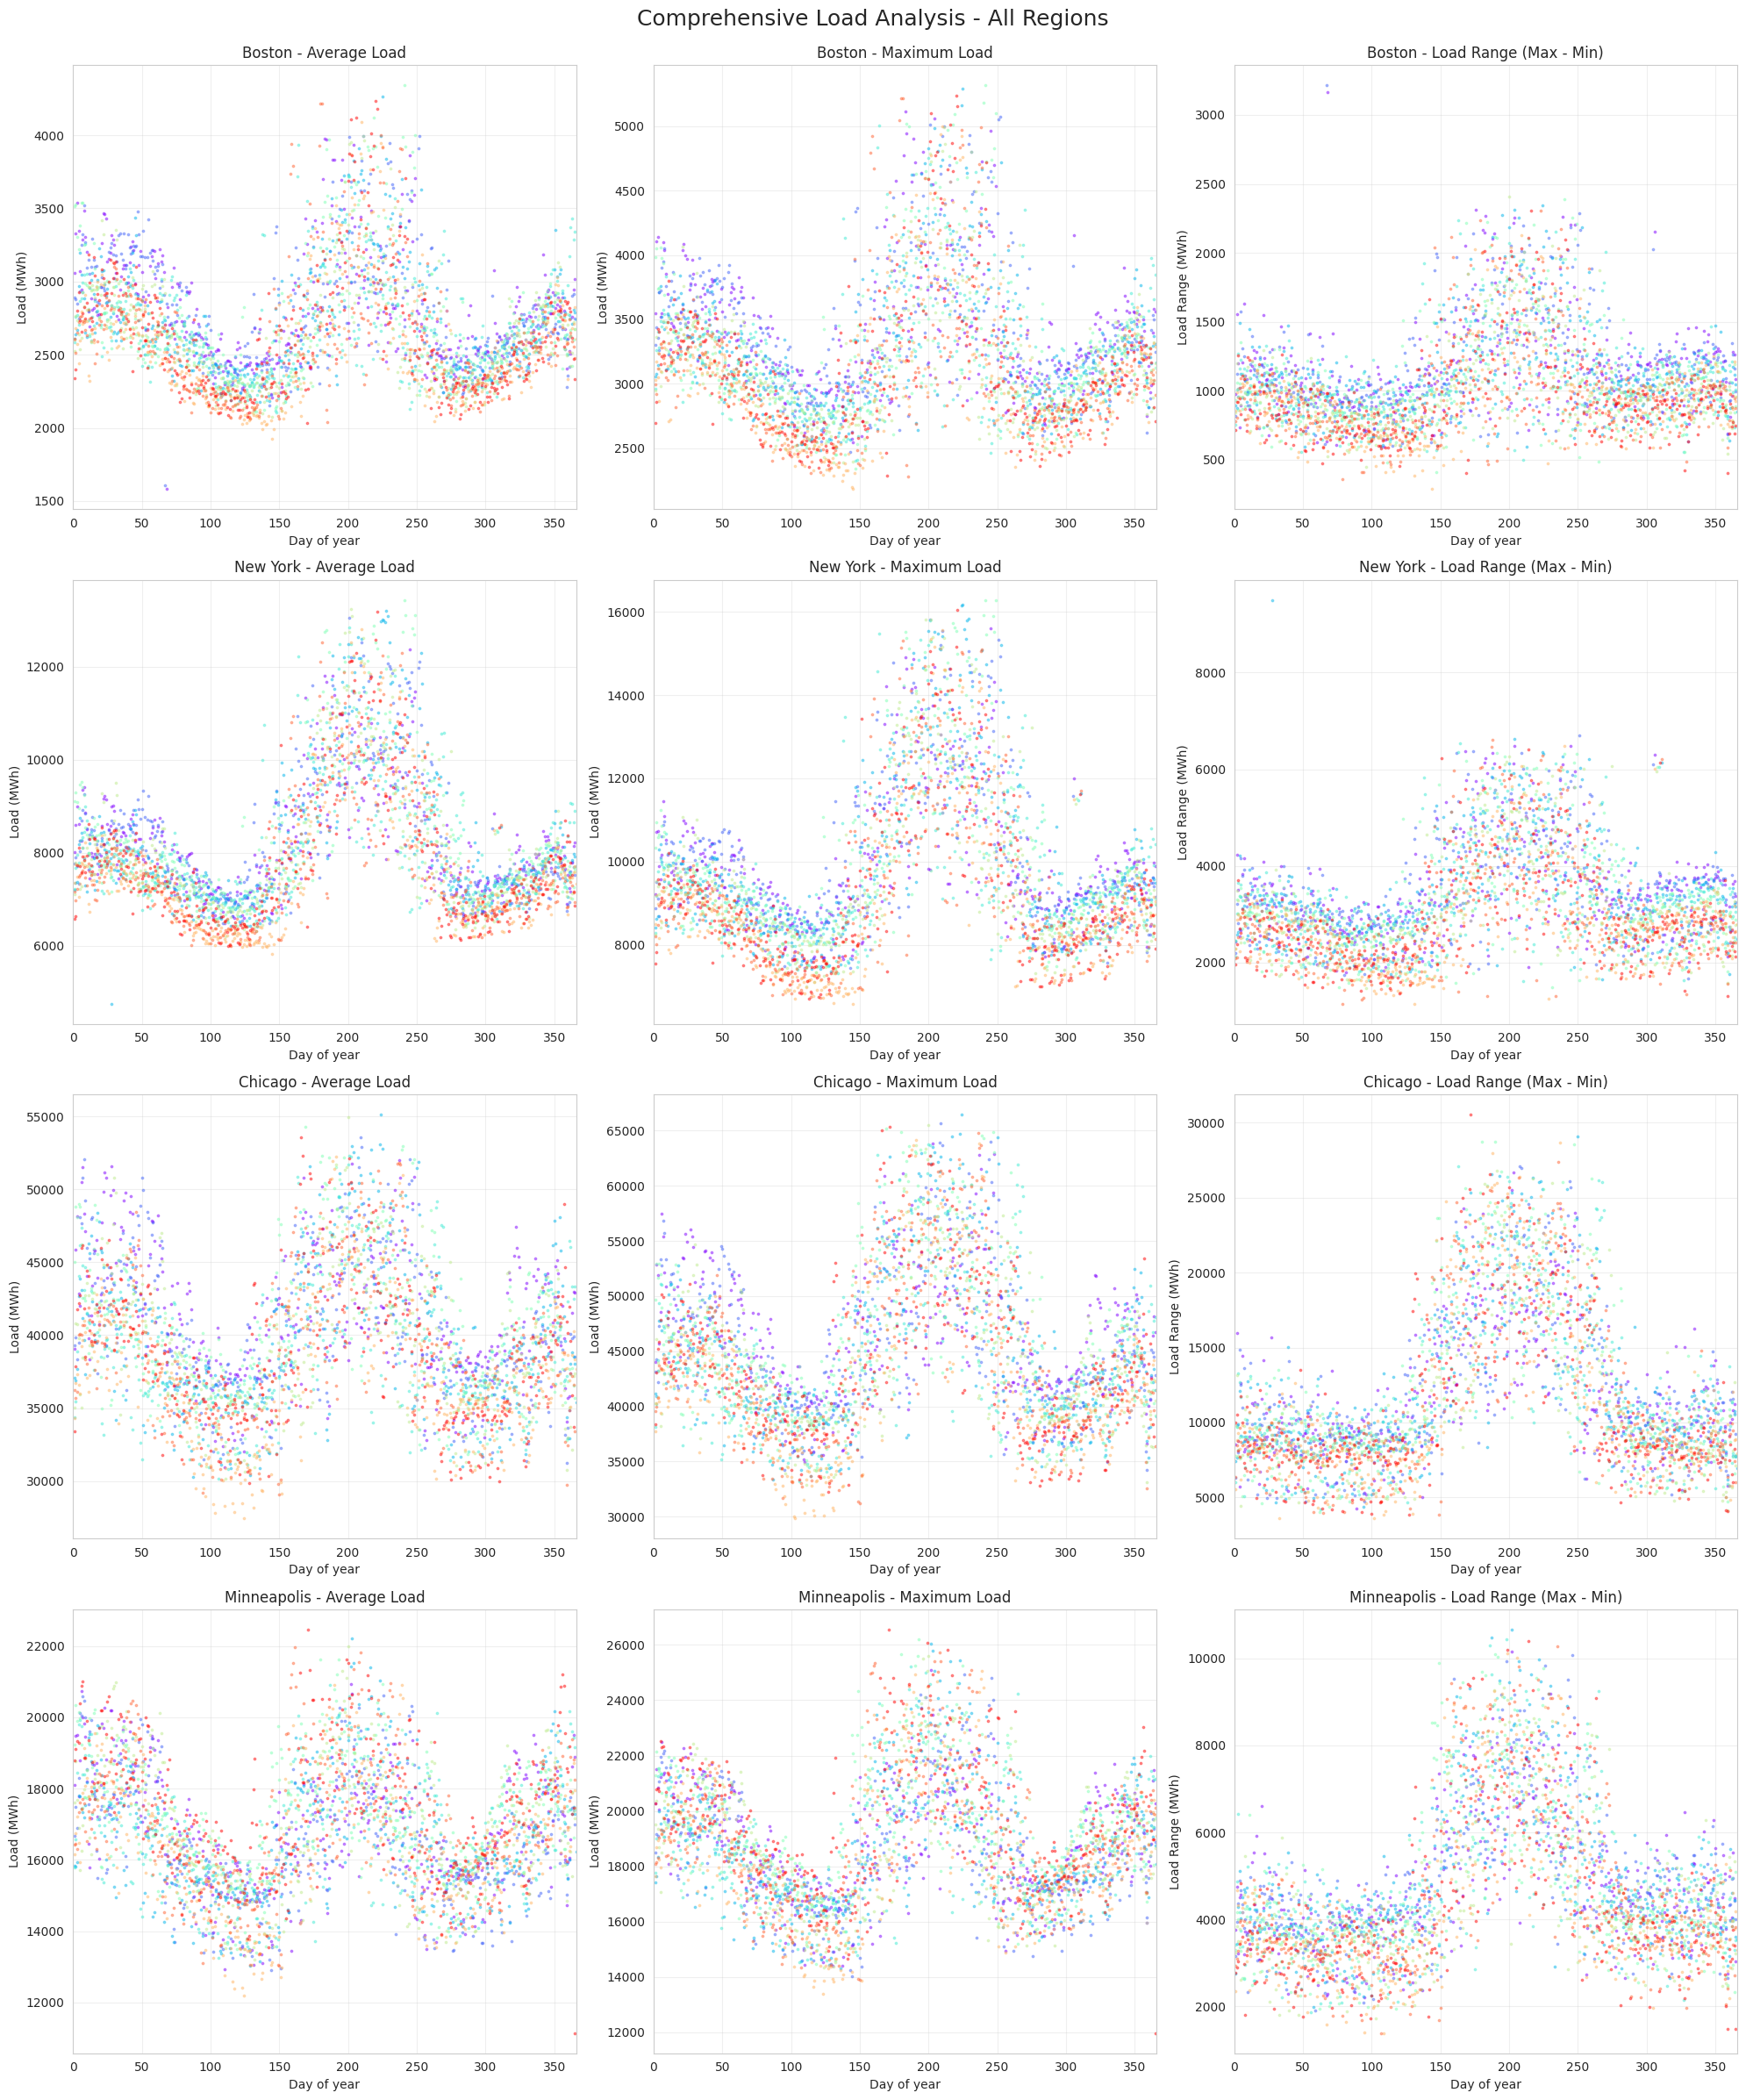

In [13]:
# Comprehensive comparison: Max, Min, and Range for all 6 regions
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(20, 24))

regions_data = {
    'Boston': df_boston,
    'New York': df_ny,
    # 'Houston': df_houston,
    'Chicago': df_chicago,
    # 'Dallas': df_dallas,
    'Minneapolis': df_minneapolis,
}

for i, (region_name, df_region) in enumerate(regions_data.items()):
    # Average Load
    plot_day_of_year(
        df_region['avg_load'],
        is_scatter=True,
        title=f"{region_name} - Average Load",
        ylabel="Load (MWh)",
        alpha=0.4,
        ax=axes[i, 0],
    )
    
    # Max Load
    plot_day_of_year(
        df_region['max_load'],
        is_scatter=True,
        title=f"{region_name} - Maximum Load",
        ylabel="Load (MWh)",
        alpha=0.4,
        ax=axes[i, 1],
    )
    
    # Load Range
    load_range = df_region['max_load'] - df_region['min_load']
    plot_day_of_year(
        load_range,
        is_scatter=True,
        title=f"{region_name} - Load Range (Max - Min)",
        ylabel="Load Range (MWh)",
        alpha=0.4,
        ax=axes[i, 2],
    )

# Set x-axis limits for all subplots
for ax in axes.flatten():
    ax.set_xlim(0, 366)

plt.suptitle('Comprehensive Load Analysis - All Regions', fontsize=18, y=0.995)
plt.tight_layout()
plt.savefig('../data/processed/comprehensive_all_regions.png', dpi=150, bbox_inches='tight')
plt.show()

## Compare Multiple Regions

In [14]:
regions = {
    'Boston': df_boston['avg_load'],
    'New York': df_ny['avg_load'] if 'avg_load' in df_ny.columns else None,
    # 'Houston': df_houston['avg_load'] if 'avg_load' in df_houston.columns else None,
    'Chicago': df_chicago['avg_load'] if 'avg_load' in df_chicago.columns else None,
    # 'Dallas': df_dallas['avg_load'] if 'avg_load' in df_dallas.columns else None,
    'Minneapolis': df_minneapolis['avg_load'] if 'avg_load' in df_minneapolis.columns else None,
}

## Seasonal Pattern Fitting

Fit sinusoidal + trend model to capture seasonal patterns

In [15]:
# Fit model for Boston average load
region_fit = {}


for city in regions.keys():
    region_fit[city] = fit_seasonal_model(regions[city], n_harmonics=3)
    print(f"{city} Model R²:", 1 - np.var(region_fit[city]['residuals']) / np.var(region_fit[city]['y']))
    print(f"{city} Residuals mean:", region_fit[city]['residuals'].mean())
    print(f"{city} Residuals std:", region_fit[city]['residuals'].std())

Boston Model R²: 0.5240592795447503
Boston Residuals mean: 4.853774280042807e-12
Boston Residuals std: 270.5004217526661
New York Model R²: 0.702141816619801
New York Residuals mean: 1.0745706187421187e-11
New York Residuals std: 791.3075672176666
Chicago Model R²: 0.4776335610974207
Chicago Residuals mean: 4.5852261191269136e-11
Chicago Residuals std: 3553.7009213932092
Minneapolis Model R²: 0.4638980672677836
Minneapolis Residuals mean: 3.5837466922308994e-11
Minneapolis Residuals std: 1275.5663855435412


## Visualize Fitted Model and Residuals

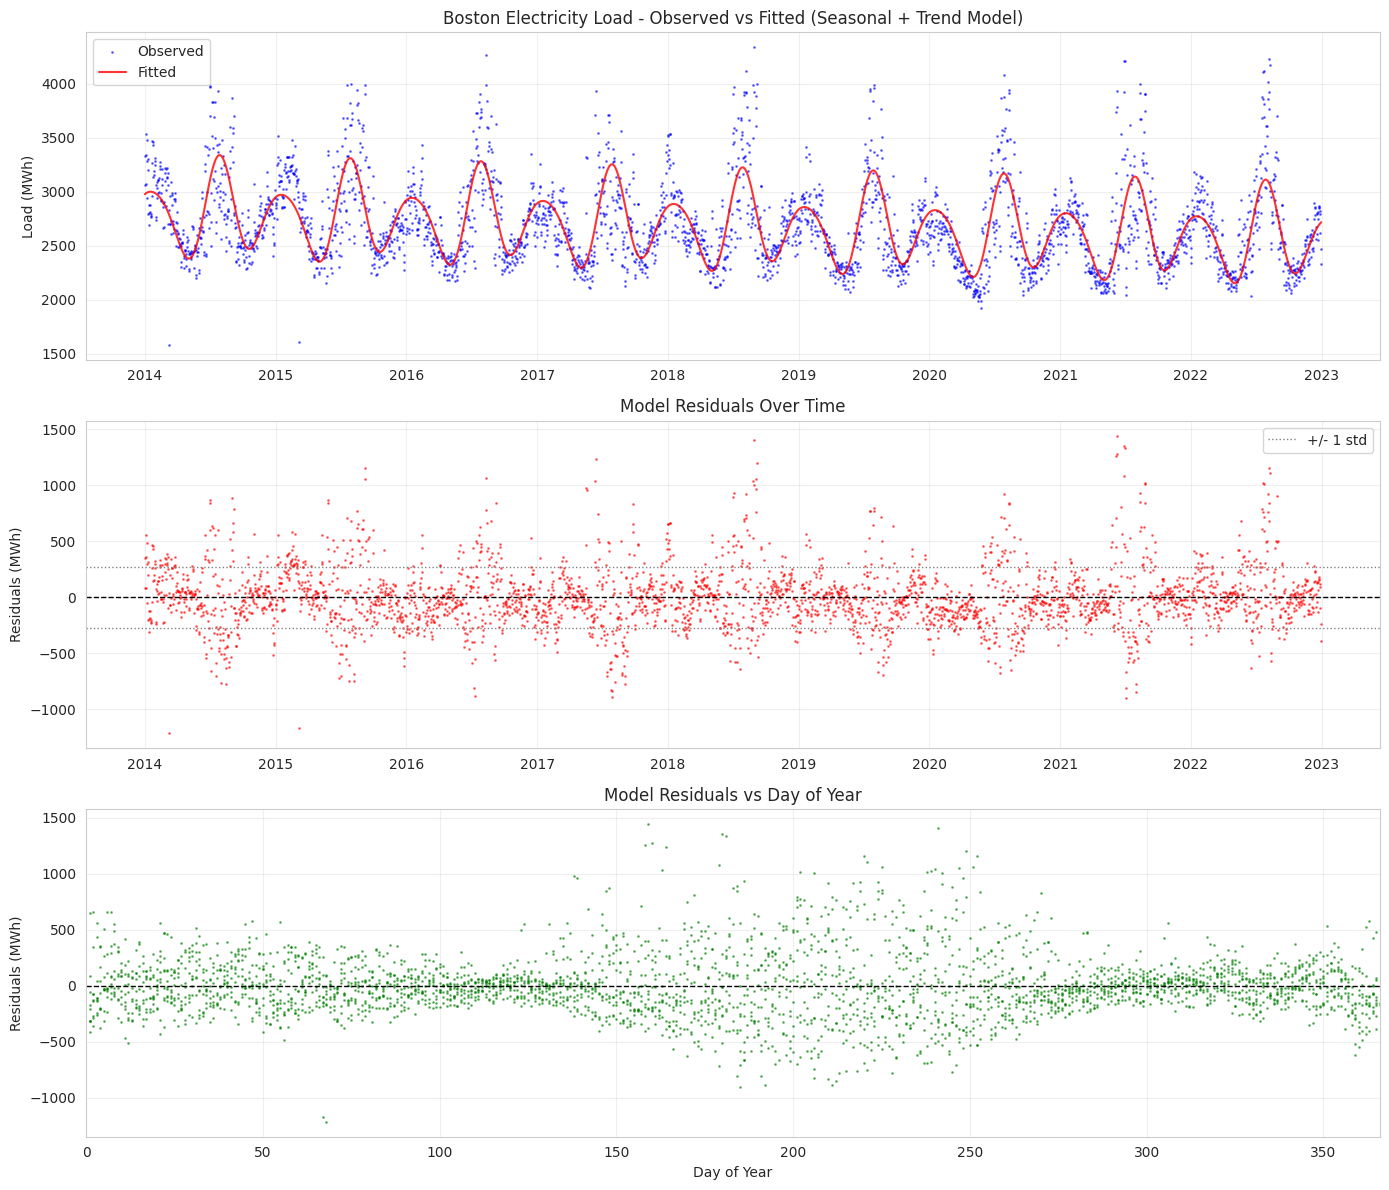

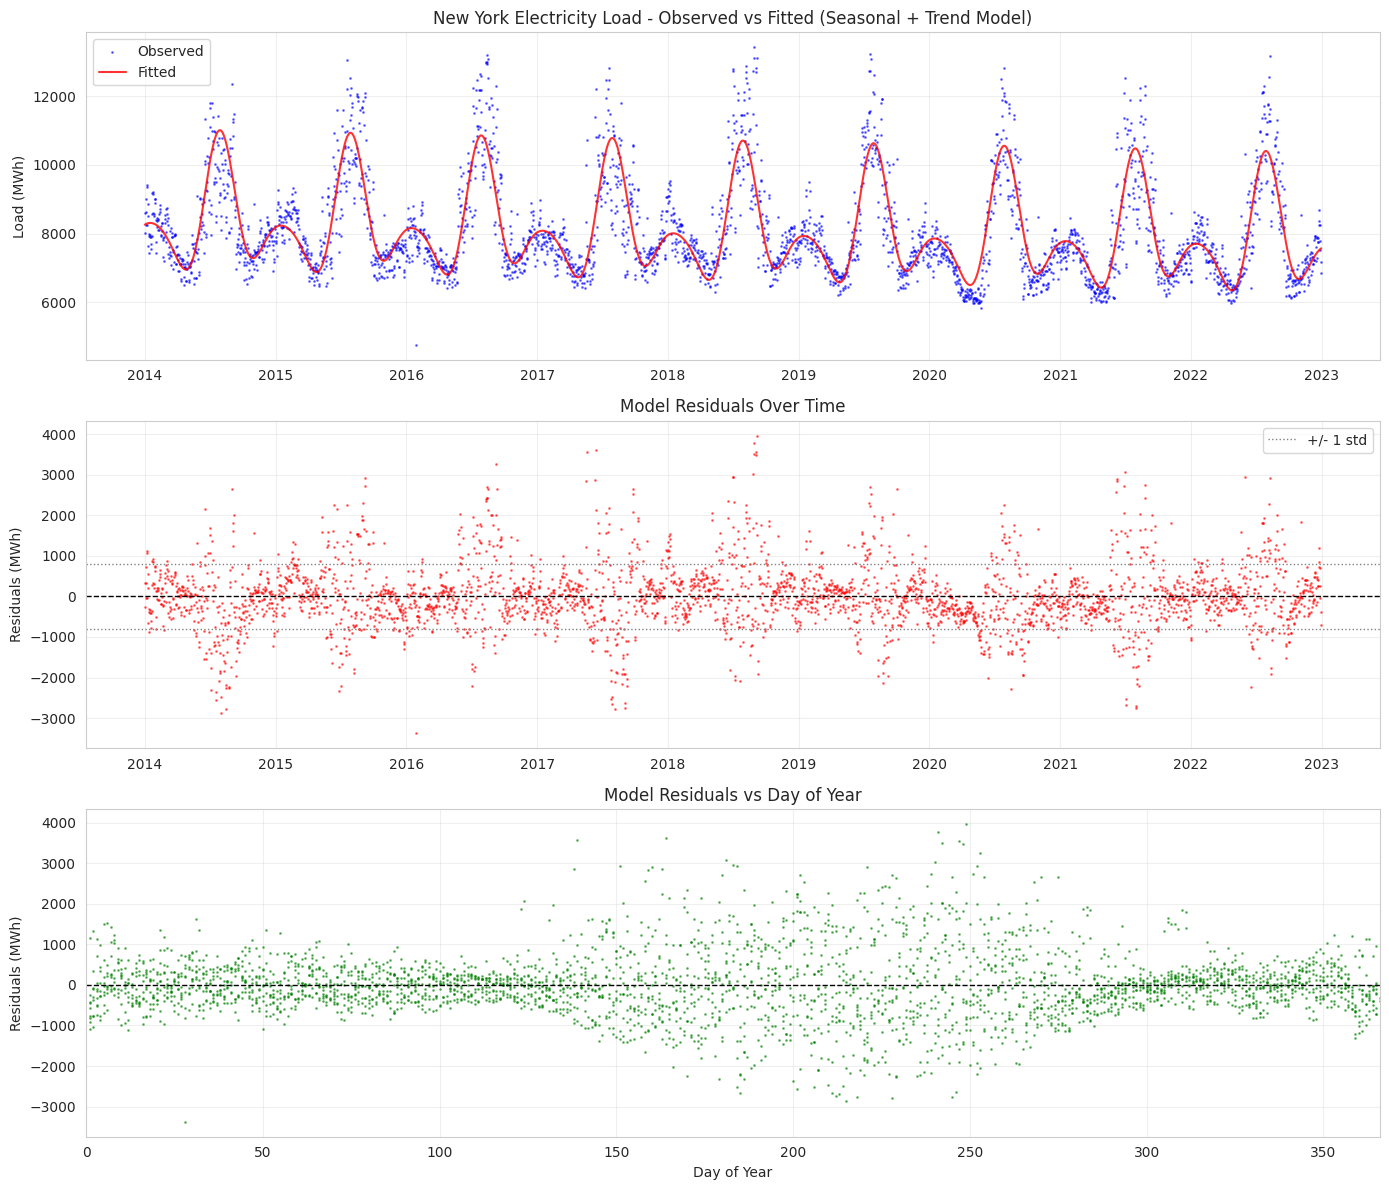

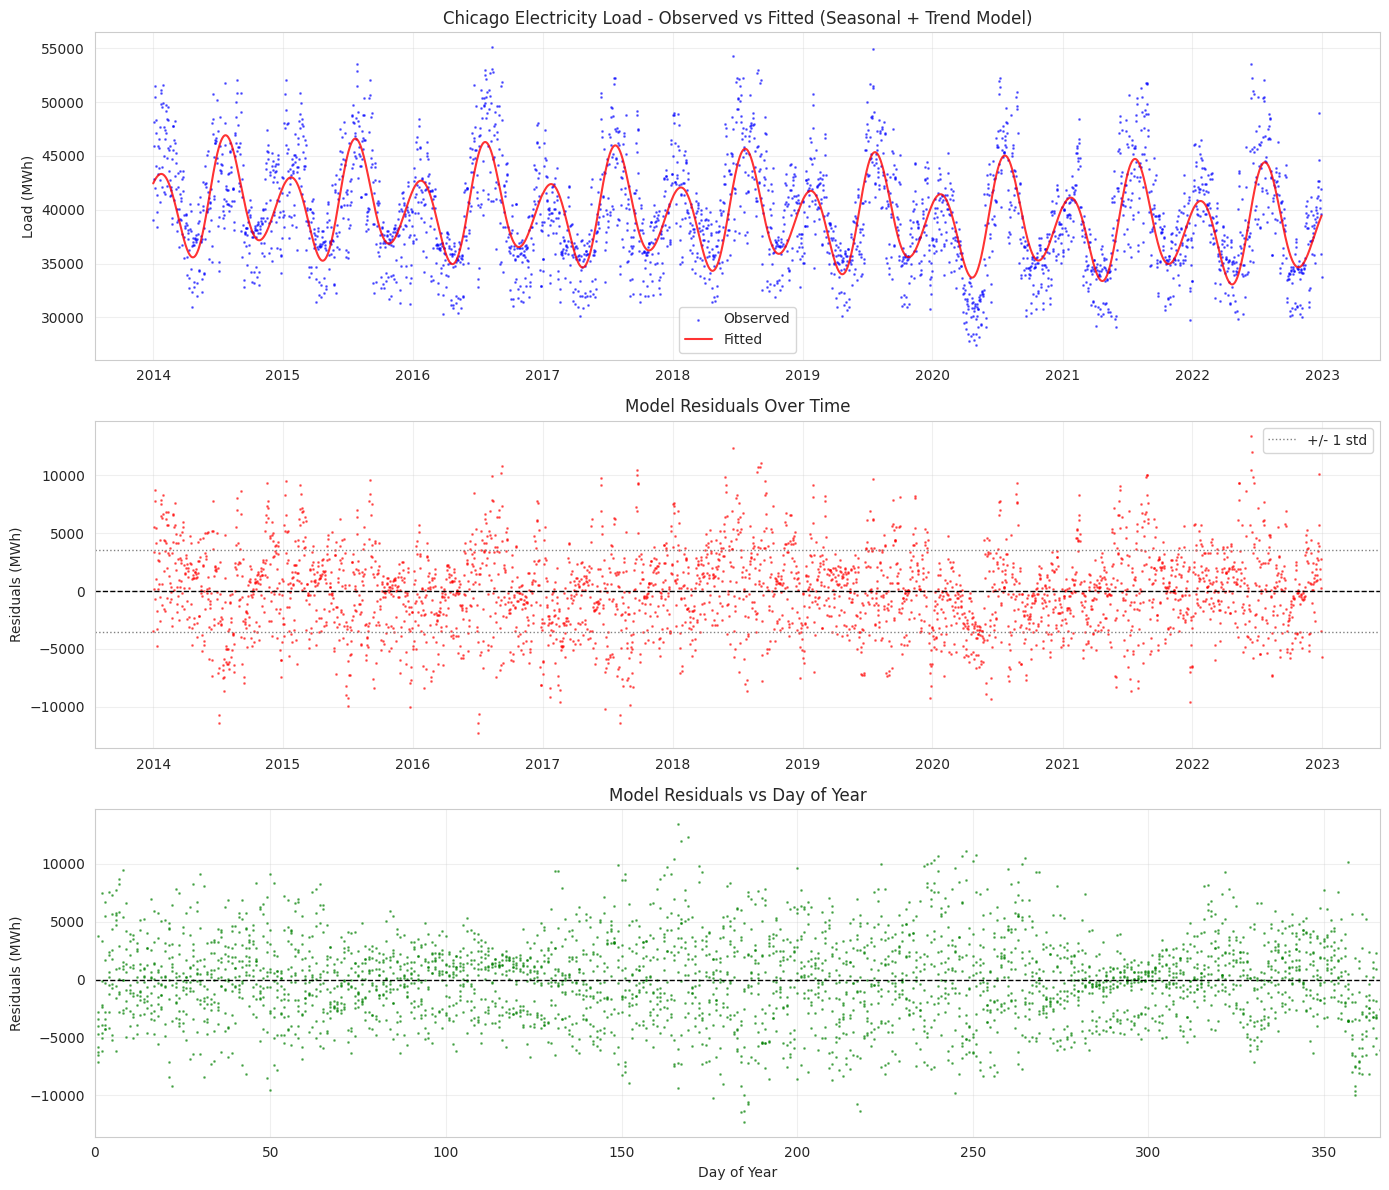

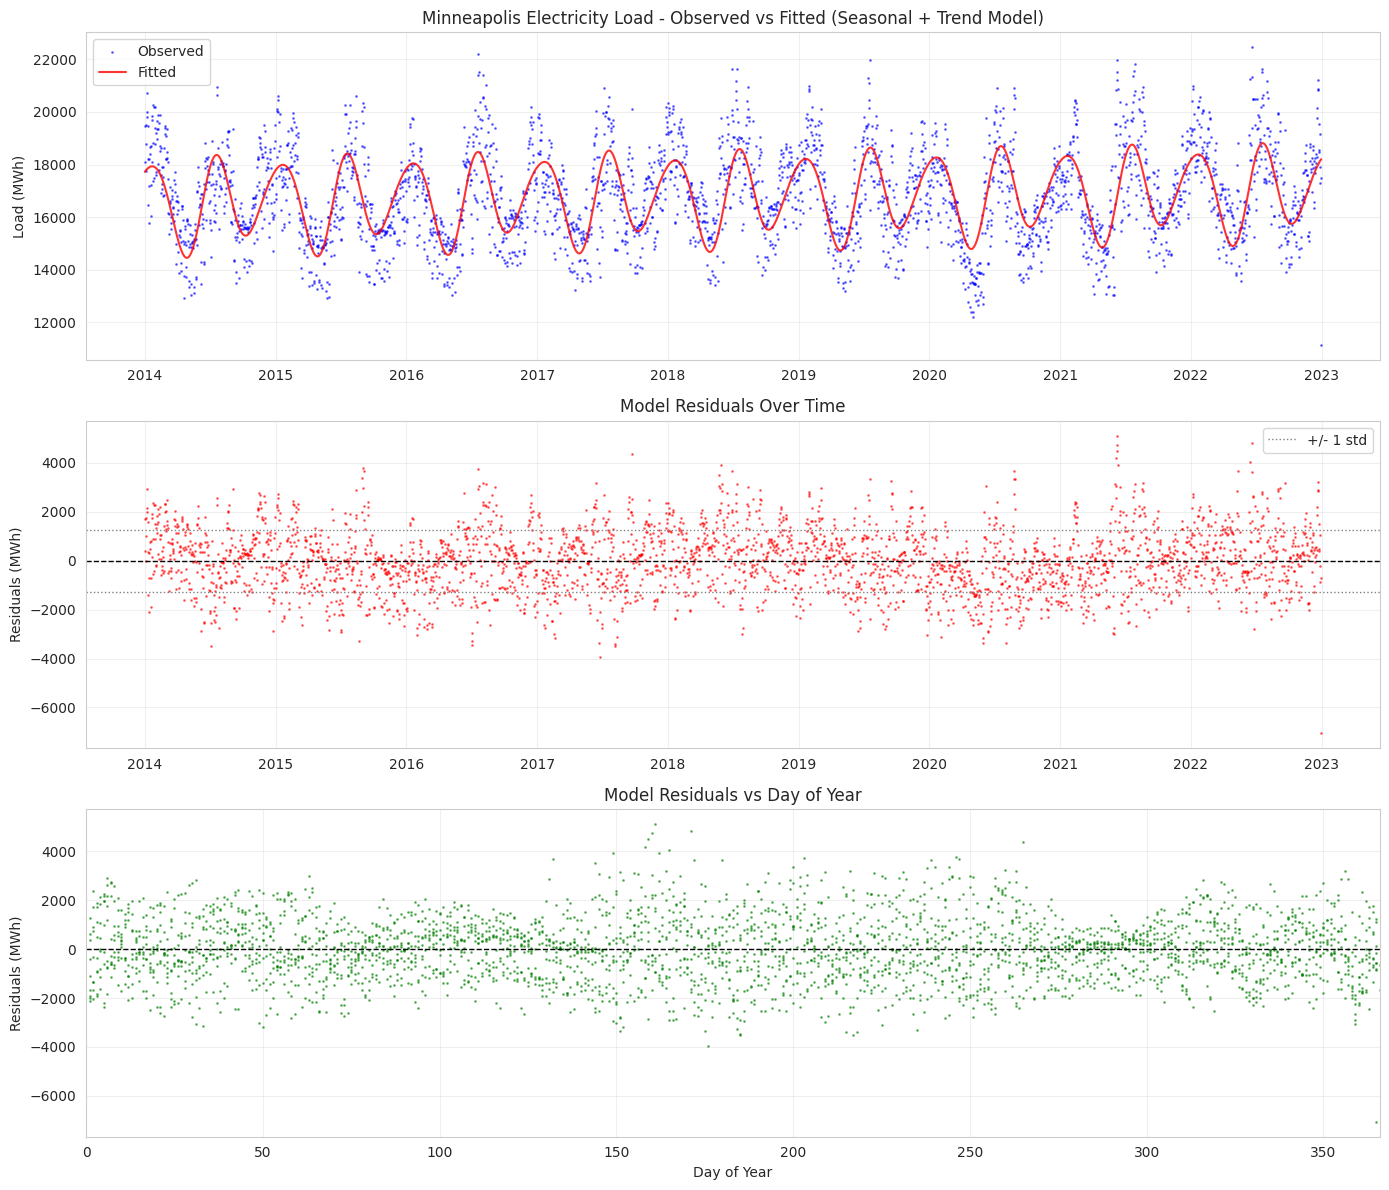

In [16]:
for city in regions.keys():
# Visualize fitted model and residuals using helper function
        plot_fitted_model_and_residuals(
            region_fit[city], 
            city,
            save_path=f'../data/images/model_fit_and_residuals_{city}.png'
        )
        plt.show()

## Residual Distribution Analysis


Boston - RESIDUAL NORMALITY TEST
D'Agostino-Pearson test: statistic=477.9605, p-value=1.6301e-104
Reject normality (p < 0.05): True



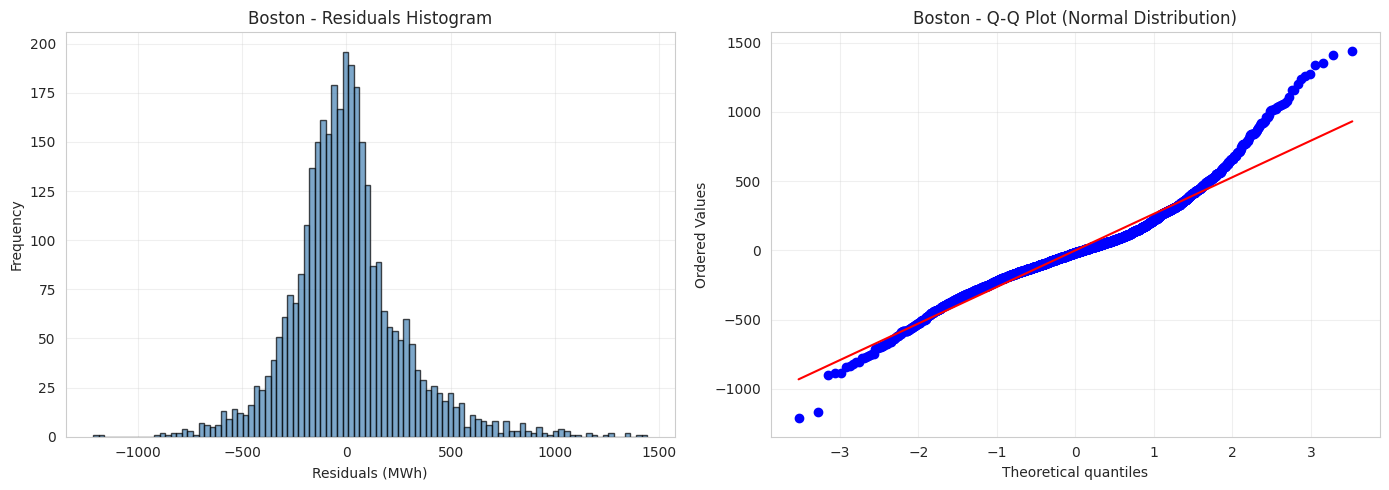


New York - RESIDUAL NORMALITY TEST
D'Agostino-Pearson test: statistic=328.1560, p-value=5.5187e-72
Reject normality (p < 0.05): True



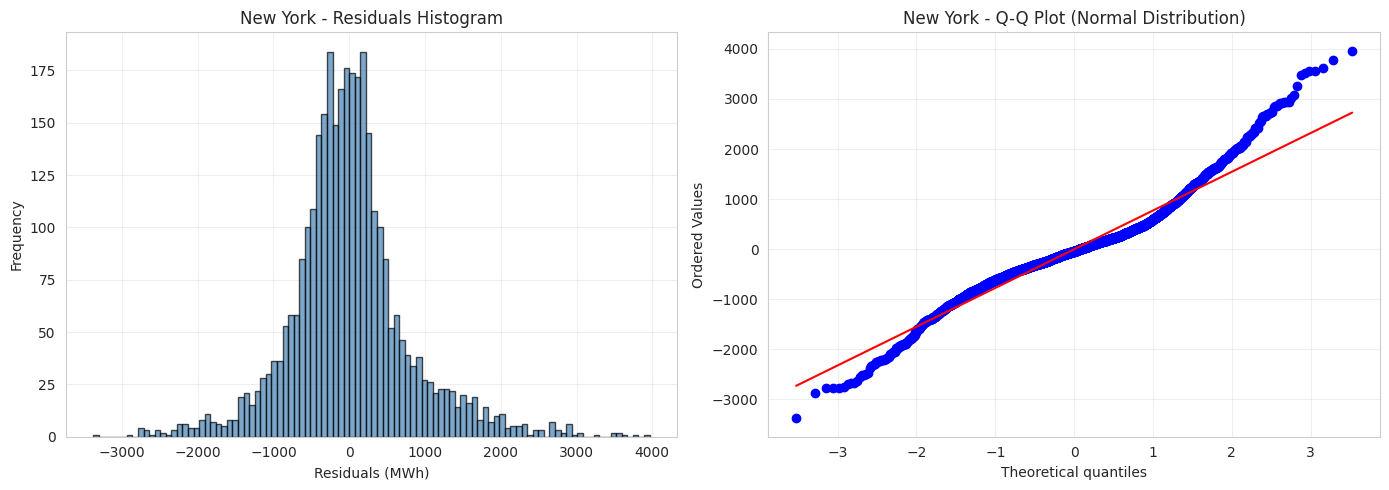


Chicago - RESIDUAL NORMALITY TEST
D'Agostino-Pearson test: statistic=11.1612, p-value=3.7703e-03
Reject normality (p < 0.05): True



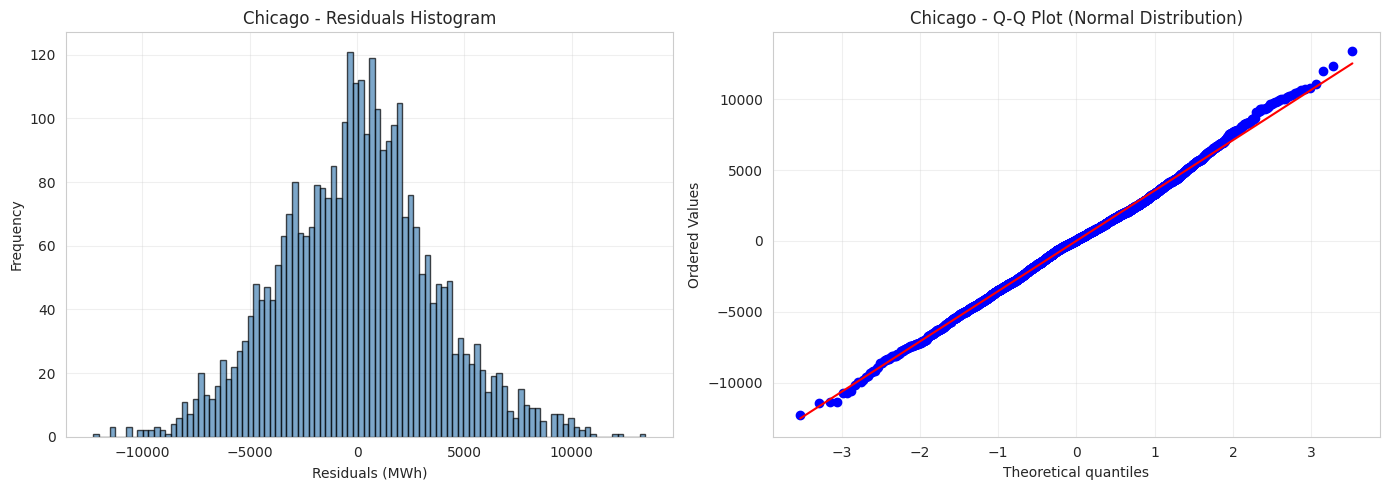


Minneapolis - RESIDUAL NORMALITY TEST
D'Agostino-Pearson test: statistic=18.1854, p-value=1.1248e-04
Reject normality (p < 0.05): True



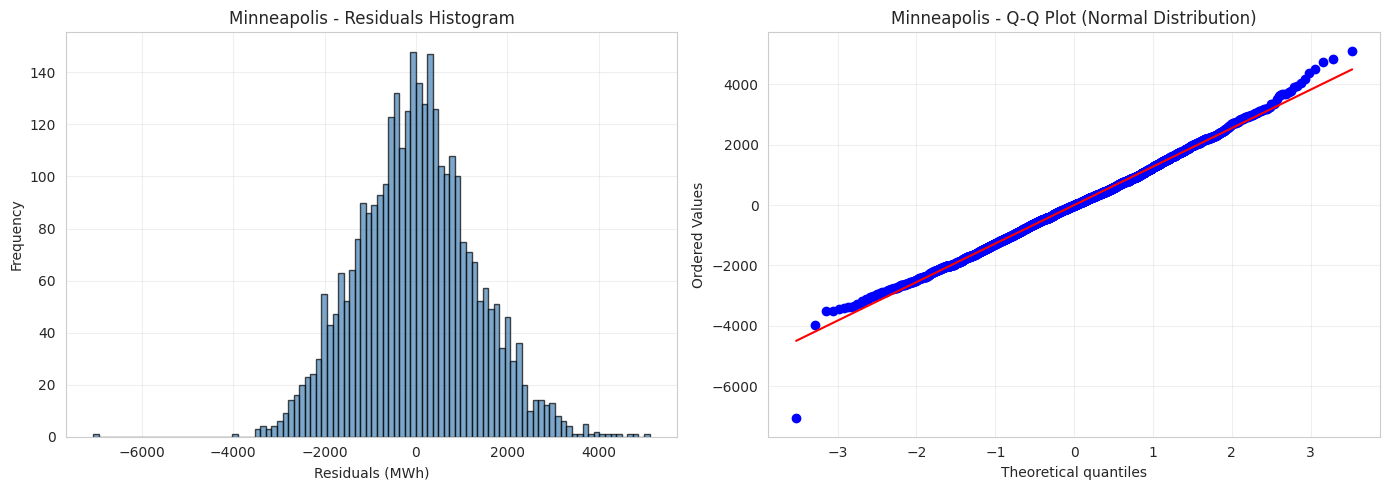

In [17]:
# Analyze residual distribution using helper function

for city in regions.keys():
    plot_residual_distribution(
        region_fit[city],
        city,
        save_path=f'../data/images/residual_distribution_{city}.png'
    )
    plt.show()

## Autocorrelation Analysis

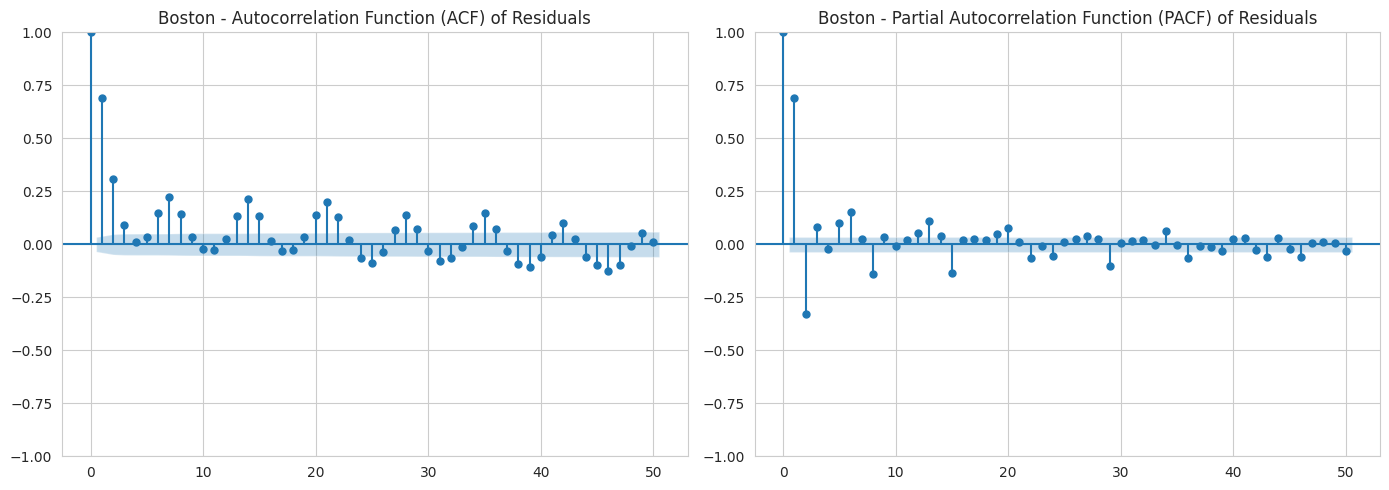

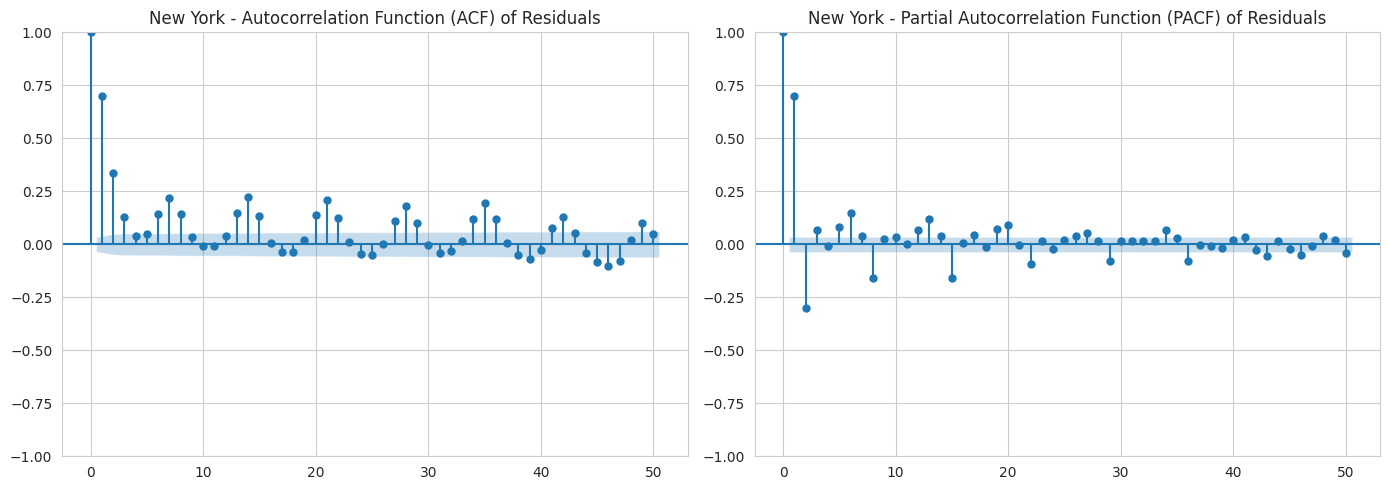

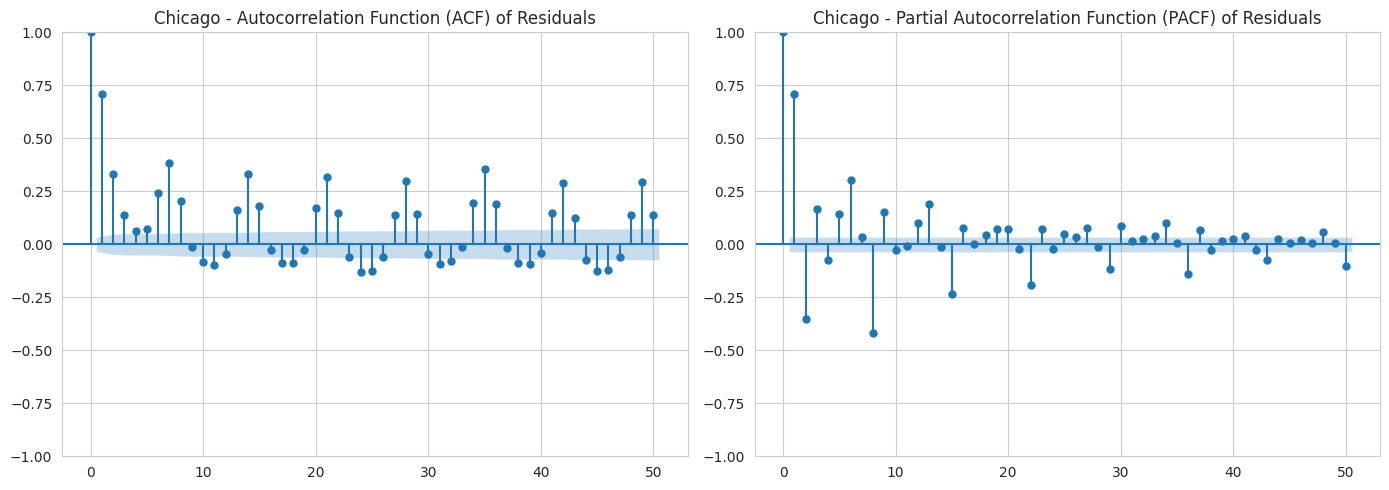

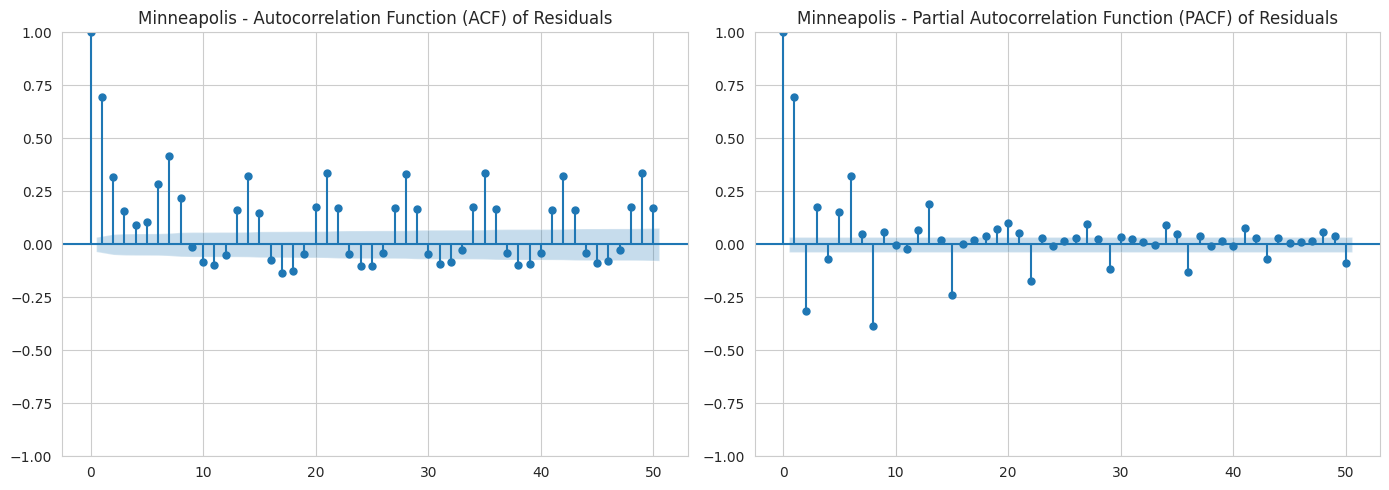

In [18]:
# Plot autocorrelation functions using helper function
for city in regions.keys():
    plot_autocorrelation(
        region_fit[city],
        city,
        lags=50,
        save_path=f'../data/images/autocorrelation_{city}.png'
    )
    plt.show()

## Volatility Clustering Analysis

Check if residuals exhibit volatility clustering (periods of high volatility followed by high volatility, and low volatility followed by low volatility)


Boston - LJUNG-BOX TEST (Test for ARCH Effects)
        lb_stat      lb_pvalue
1   1117.354450  5.584968e-245
2   1340.436638  8.469980e-292
3   1435.259977  6.576027e-311
4   1530.579767   0.000000e+00
5   1626.310016   0.000000e+00
6   1717.304775   0.000000e+00
7   1815.625389   0.000000e+00
8   1895.309462   0.000000e+00
9   1949.409265   0.000000e+00
10  1993.102581   0.000000e+00

If p-values < 0.05, reject null hypothesis of no autocorrelation
This indicates presence of ARCH effects (volatility clustering)

Number of significant lags (out of 20): 20
⚠️  Strong evidence of volatility clustering!

Boston - ARCH LM TEST (Engle's Test)

Lag 1:
  LM Statistic: 1116.1240, p-value: 1.0338e-244
  F Statistic:  1689.1986, p-value: 2.7284e-298
  ⚠️  Reject null hypothesis - ARCH effects present at lag 1

Lag 5:
  LM Statistic: 1186.4496, p-value: 2.5295e-254
  F Statistic:  370.9583, p-value: 7.7184e-316
  ⚠️  Reject null hypothesis - ARCH effects present at lag 5

Lag 10:
  LM Statistic

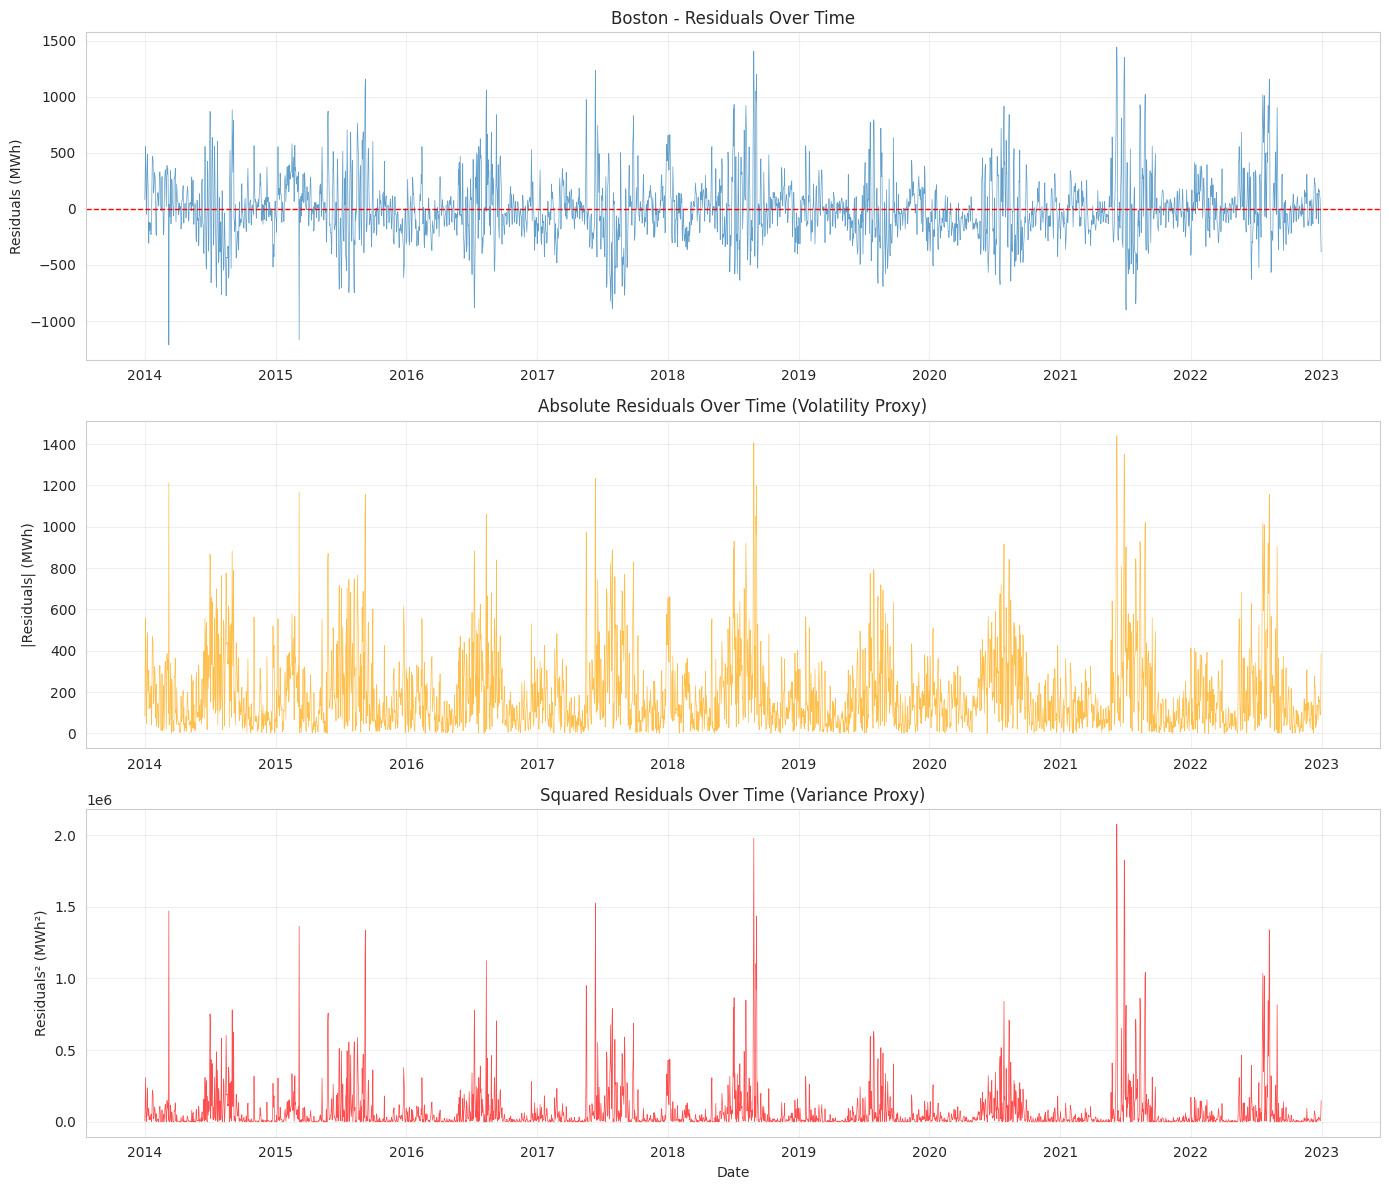

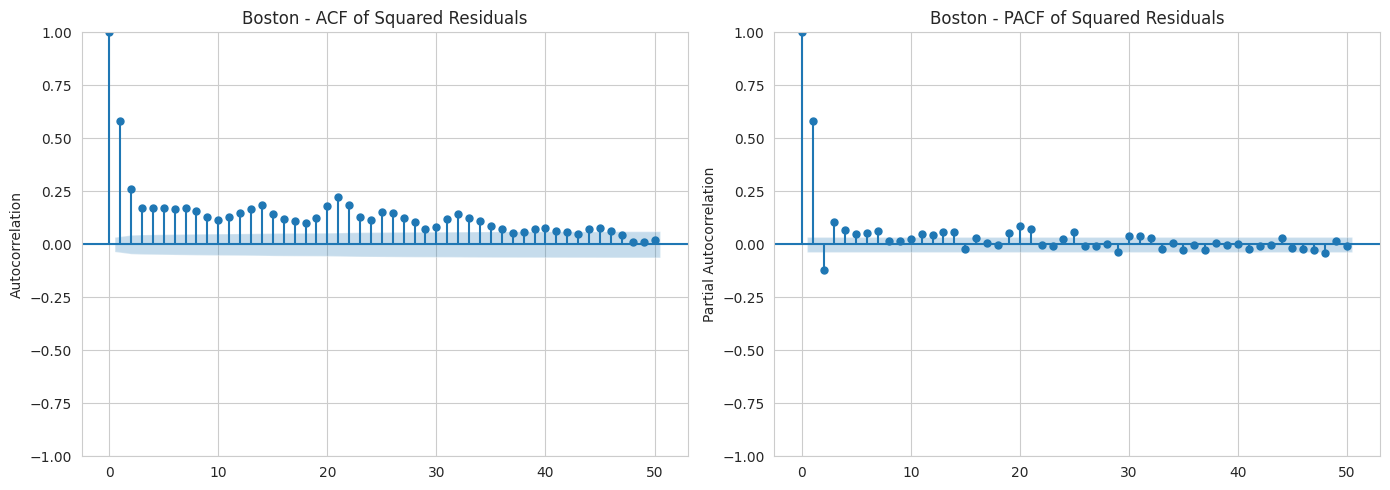

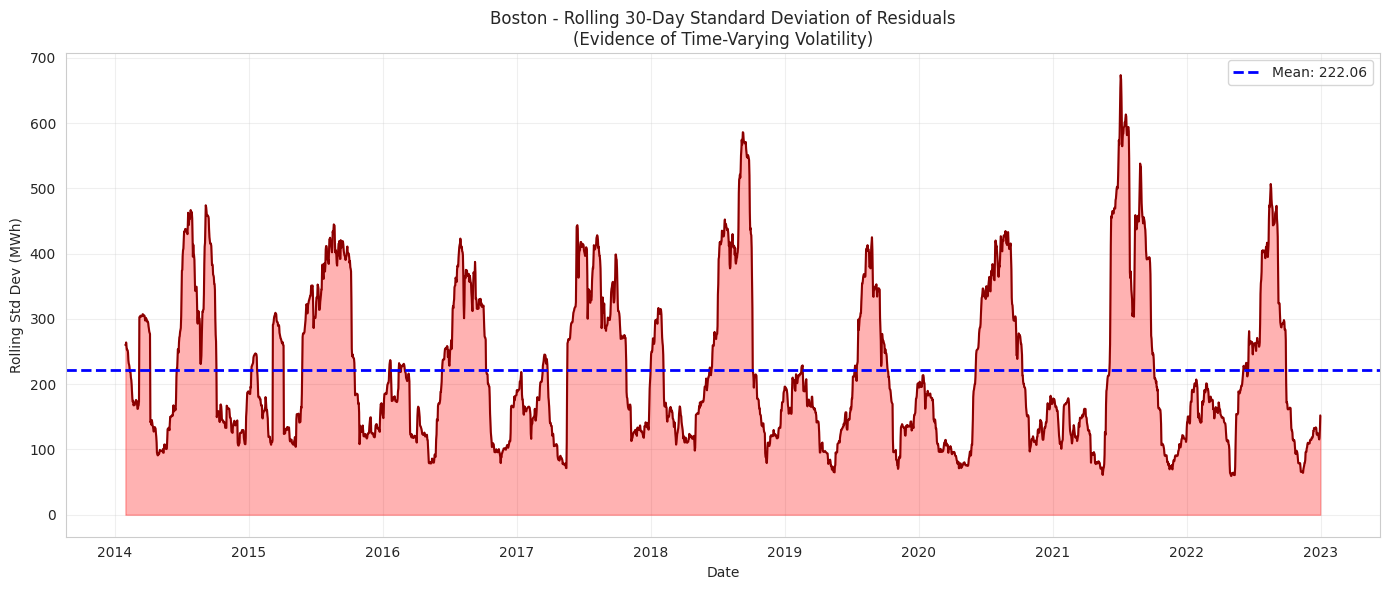

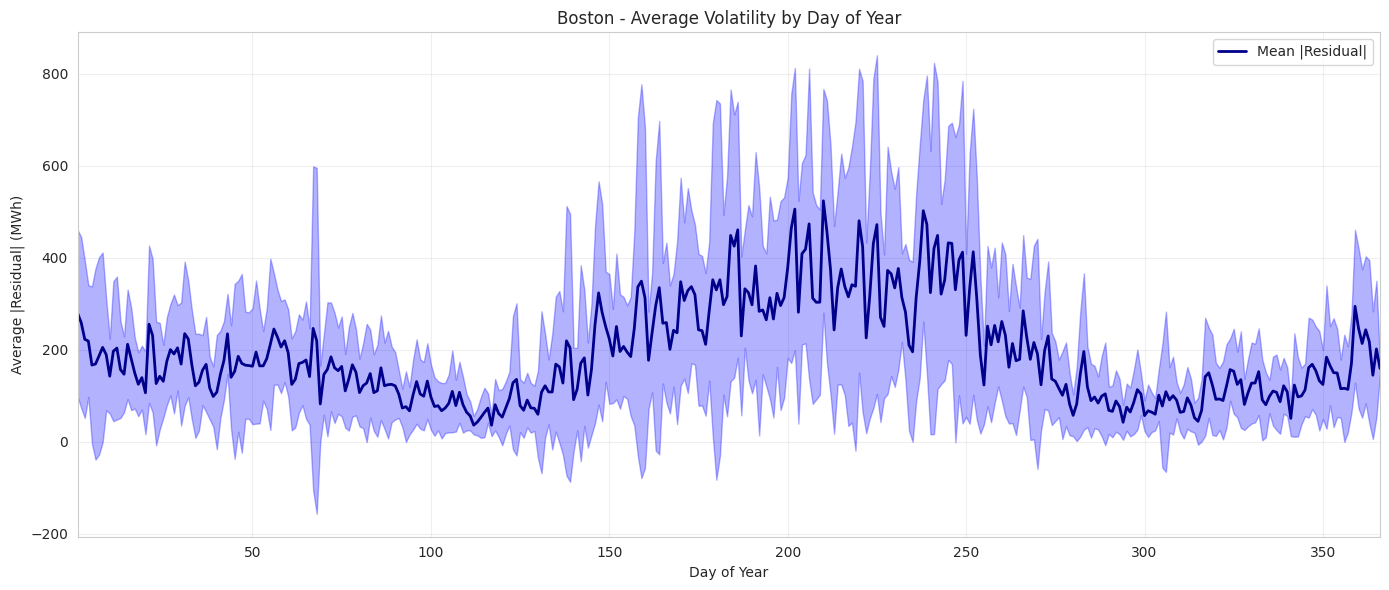


VOLATILITY CLUSTERING SUMMARY
Significant lags in Ljung-Box test: 20/20
See detailed test results above for ARCH LM test and other diagnostics


In [19]:
# Comprehensive volatility clustering analysis using helper function
# This runs ALL 6 volatility clustering tests and visualizations
volatility_results = analyze_volatility_clustering(
    region_fit['Boston'],
    'Boston',
    save_dir='../data/processed/Boston'
)
plt.show()

print("\n" + "="*80)
print("VOLATILITY CLUSTERING SUMMARY")
print("="*80)
print(f"Significant lags in Ljung-Box test: {volatility_results['significant_lags']}/20")
print("See detailed test results above for ARCH LM test and other diagnostics")
print("="*80)

## Day of Year Binned Analysis

Average load by day of year across all years

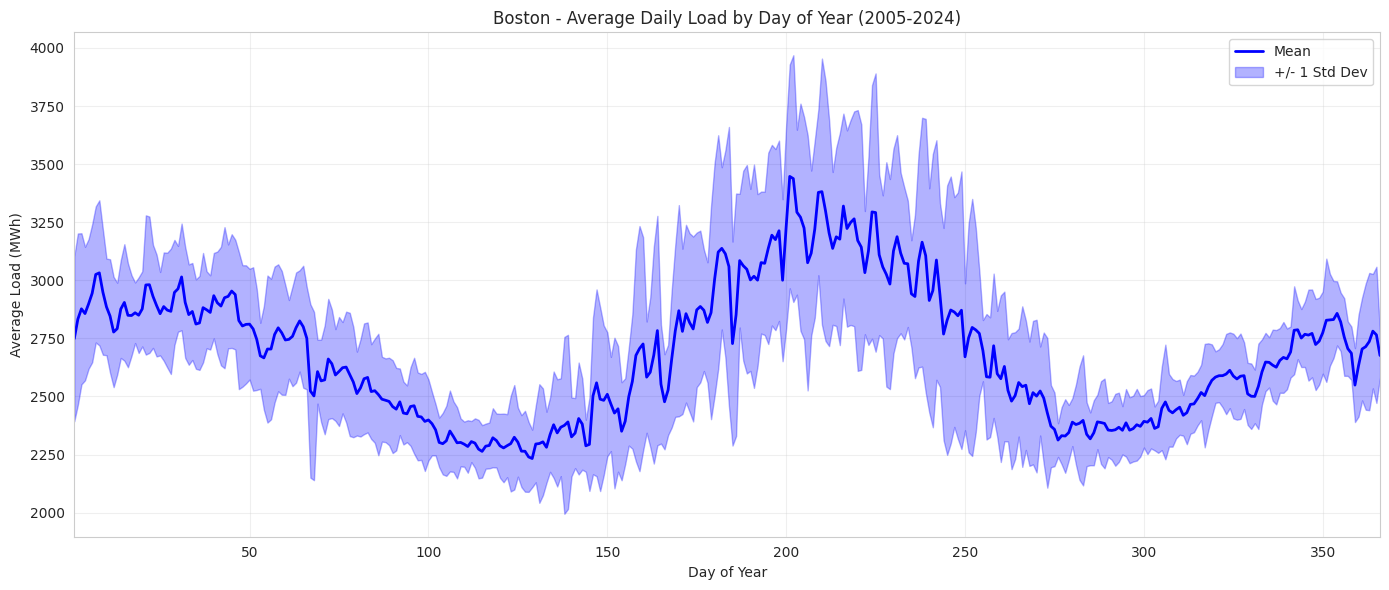

In [20]:
# Calculate average load by day of year
boston_avg_by_doy = df_boston['avg_load'].groupby(df_boston.index.day_of_year).mean()
boston_std_by_doy = df_boston['avg_load'].groupby(df_boston.index.day_of_year).std()

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(boston_avg_by_doy.index, boston_avg_by_doy.values, color='blue', lw=2, label='Mean')
ax.fill_between(
    boston_avg_by_doy.index,
    boston_avg_by_doy.values - boston_std_by_doy.values,
    boston_avg_by_doy.values + boston_std_by_doy.values,
    alpha=0.3,
    color='blue',
    label='+/- 1 Std Dev'
)

ax.set_xlabel('Day of Year')
ax.set_ylabel('Average Load (MWh)')
ax.set_title('Boston - Average Daily Load by Day of Year (2005-2024)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(1, 366)

plt.tight_layout()
plt.savefig('../data/processed/Boston/average_by_doy.png', dpi=150, bbox_inches='tight')
plt.show()

## Forecast vs Actual Load Comparison

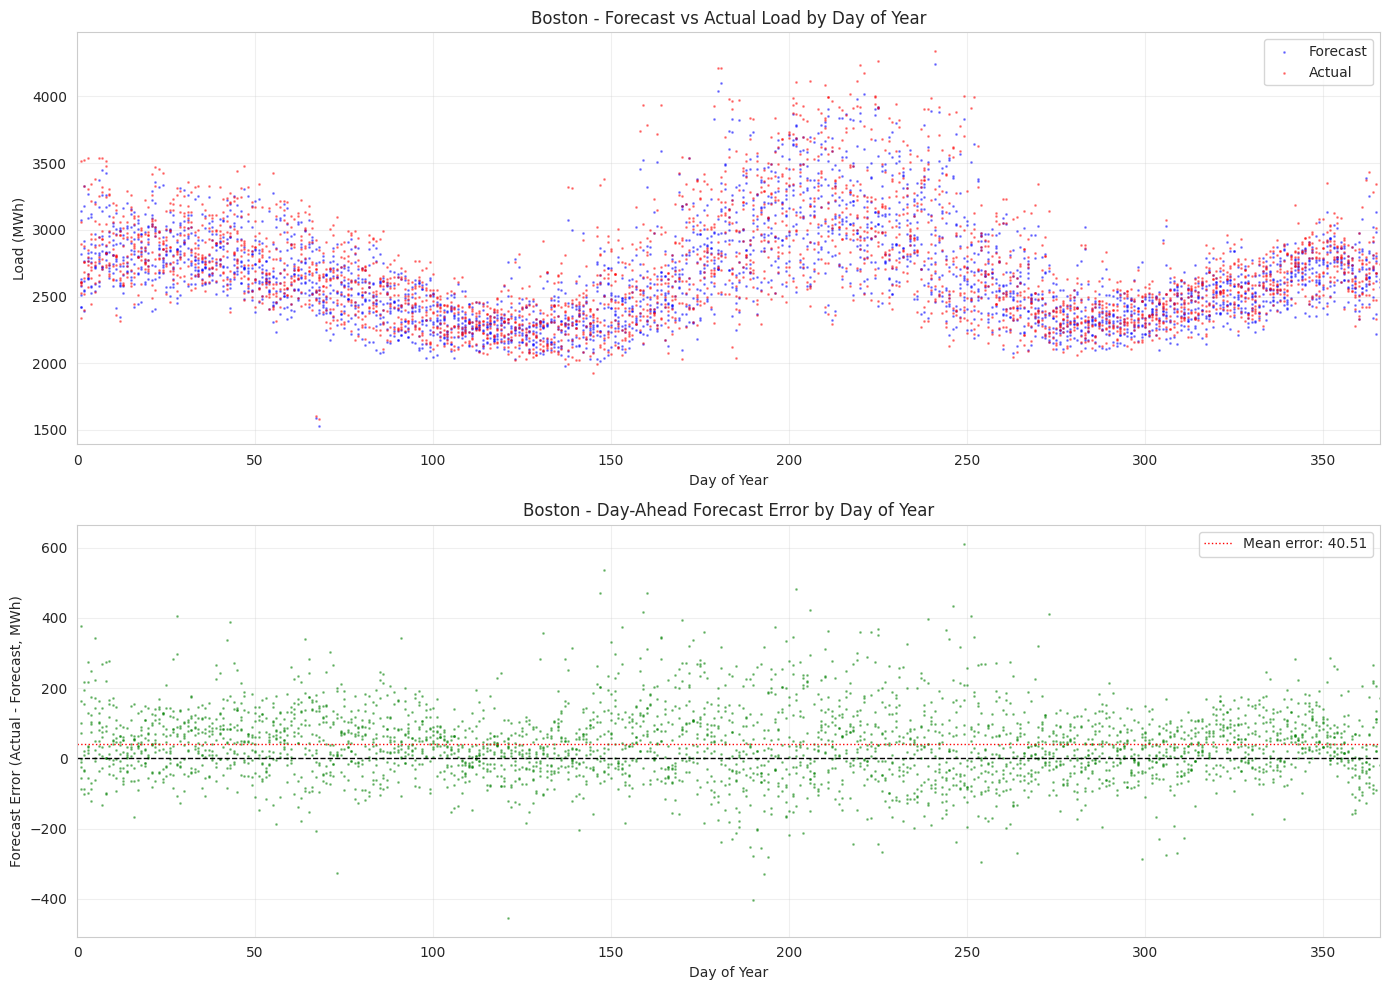

Forecast error mean: 40.51 MWh
Forecast error std: 100.41 MWh
MAPE: 2.94%


In [21]:
# Compare forecast (DA_DEMD) vs actual
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 10))

# Day of year comparison
doy = df_boston.index.day_of_year.to_numpy()
axes[0].scatter(doy, df_boston['pred_avg'], s=1, alpha=0.4, color='blue', label='Forecast')
axes[0].scatter(doy, df_boston['avg_load'], s=1, alpha=0.4, color='red', label='Actual')
axes[0].set_xlabel('Day of Year')
axes[0].set_ylabel('Load (MWh)')
axes[0].set_title('Boston - Forecast vs Actual Load by Day of Year')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 366)

# Forecast error
forecast_error = df_boston['avg_load'] - df_boston['pred_avg']
axes[1].scatter(doy, forecast_error, s=1, alpha=0.4, color='green')
axes[1].axhline(0, color='black', linestyle='--', lw=1)
axes[1].axhline(forecast_error.mean(), color='red', linestyle=':', lw=1, label=f'Mean error: {forecast_error.mean():.2f}')
axes[1].set_xlabel('Day of Year')
axes[1].set_ylabel('Forecast Error (Actual - Forecast, MWh)')
axes[1].set_title('Boston - Day-Ahead Forecast Error by Day of Year')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, 366)

plt.tight_layout()
plt.savefig('../data/processed/Boston/forecast_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Forecast error mean: {forecast_error.mean():.2f} MWh")
print(f"Forecast error std: {forecast_error.std():.2f} MWh")
print(f"MAPE: {(np.abs(forecast_error) / df_boston['avg_load']).mean() * 100:.2f}%")

## Summary Statistics

In [22]:
# Summary table
summary_stats = pd.DataFrame({
    'Metric': ['Mean', 'Std', 'Min', 'Max', 'Range'],
    'Actual Load': [
        df_boston['avg_load'].mean(),
        df_boston['avg_load'].std(),
        df_boston['avg_load'].min(),
        df_boston['avg_load'].max(),
        df_boston['avg_load'].max() - df_boston['avg_load'].min(),
    ],
    'Forecast Load': [
        df_boston['pred_avg'].mean(),
        df_boston['pred_avg'].std(),
        df_boston['pred_avg'].min(),
        df_boston['pred_avg'].max(),
        df_boston['pred_avg'].max() - df_boston['pred_avg'].min(),
    ],
})

print("\nBoston Load Summary Statistics (MWh):")
print(summary_stats.to_string(index=False))


Boston Load Summary Statistics (MWh):
Metric  Actual Load  Forecast Load
  Mean  2687.922647    2647.412641
   Std   392.154847     360.391464
   Min  1582.500000    1533.450000
   Max  4340.422500    4242.500000
 Range  2757.922500    2709.050000


## GARCH Model for Residual Volatility

Model the time-varying volatility in residuals using GARCH (Generalized Autoregressive Conditional Heteroskedasticity)

In [23]:
# Fit the combined seasonal + GARCH model to Boston data
boston_garch_fit = fit_seasonal_garch_model(df_boston['avg_load'], n_harmonics=3)

print("=" * 80)
print("SEASONAL MODEL (Mean)")
print("=" * 80)
print(f"Model R²: {1 - np.var(boston_garch_fit['residuals']) / np.var(boston_garch_fit['y']):.4f}")
print(f"Residuals mean: {boston_garch_fit['residuals'].mean():.4f} MWh")
print(f"Residuals std: {boston_garch_fit['residuals'].std():.2f} MWh")

print("\n" + "=" * 80)
print("GARCH(1,1) MODEL (Volatility)")
print("=" * 80)
garch = boston_garch_fit['garch_params']
print(f"ω (omega):     {garch['omega']:.6f}")
print(f"α (alpha):     {garch['alphas'][0]:.6f}")
print(f"β (beta):      {garch['betas'][0]:.6f}")
print(f"Persistence (α+β): {boston_garch_fit['persistence']:.6f}")
print(f"\nAverage volatility: {boston_garch_fit['volatility'].mean():.2f} MWh")
print(f"Volatility range: [{boston_garch_fit['volatility'].min():.2f}, {boston_garch_fit['volatility'].max():.2f}] MWh")

print("\n" + "=" * 80)
print("INTERPRETATION")
print("=" * 80)
if boston_garch_fit['persistence'] > 0.9:
    print("⚠️  High persistence (α+β > 0.9): Volatility shocks are very persistent")
elif boston_garch_fit['persistence'] > 0.7:
    print("⚠️  Moderate persistence: Volatility shocks decay moderately")
else:
    print("✓ Low persistence: Volatility shocks decay quickly")

/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/workspaces/Financial-Engineering-Project/notebooks/seasonal_models.py:167: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'constant': armax_result.params[0],
/workspaces/Financial-Engineering-Project/notebooks/seasonal_models.py:167: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (co

SEASONAL MODEL (Mean)
Model R²: 0.7633
Residuals mean: 0.9574 MWh
Residuals std: 190.75 MWh

GARCH(1,1) MODEL (Volatility)
ω (omega):     0.175538
α (alpha):     0.172339
β (beta):      0.826996
Persistence (α+β): 0.999335

Average volatility: 162.90 MWh
Volatility range: [34.88, 1217.54] MWh

INTERPRETATION
⚠️  High persistence (α+β > 0.9): Volatility shocks are very persistent


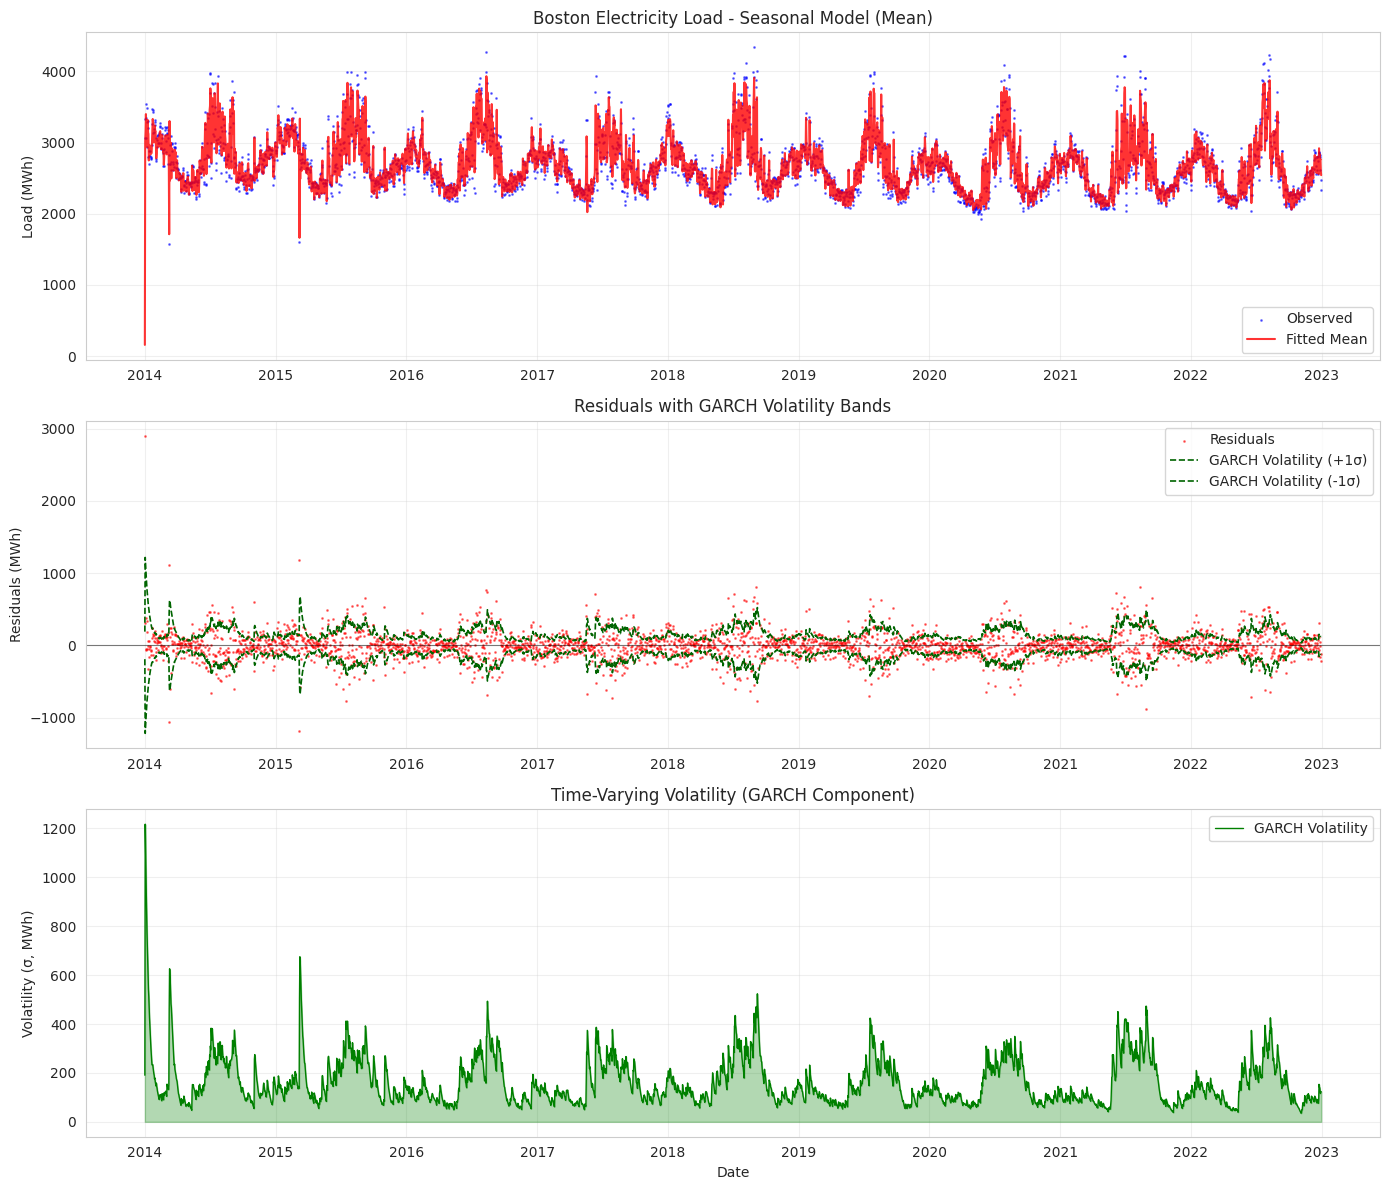


Residuals within ±1σ band: 69.3%
Residuals within ±2σ band: 92.1%
Expected (normal distribution): 68.3% within ±1σ, 95.4% within ±2σ


In [24]:
# Visualize the complete model: Mean + Volatility bands
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(14, 12))

# Panel 1: Observed vs Fitted Mean
axes[0].scatter(boston_garch_fit['index'], boston_garch_fit['y'], s=1, alpha=0.5, 
                color='blue', label='Observed')
axes[0].plot(boston_garch_fit['index'], boston_garch_fit['y_pred'], 
             color='red', lw=1.5, label='Fitted Mean', alpha=0.8)
axes[0].set_ylabel('Load (MWh)')
axes[0].set_title('Boston Electricity Load - Seasonal Model (Mean)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Panel 2: Residuals with GARCH volatility bands
axes[1].scatter(boston_garch_fit['index'], boston_garch_fit['residuals'], 
                s=1, alpha=0.5, color='red', label='Residuals')
axes[1].plot(boston_garch_fit['index'], boston_garch_fit['volatility'], 
             color='darkgreen', lw=1.2, linestyle='--', label='GARCH Volatility (+1σ)')
axes[1].plot(boston_garch_fit['index'], -boston_garch_fit['volatility'], 
             color='darkgreen', lw=1.2, linestyle='--', label='GARCH Volatility (-1σ)')
axes[1].axhline(0, color='black', linestyle='-', lw=0.8, alpha=0.5)
axes[1].set_ylabel('Residuals (MWh)')
axes[1].set_title('Residuals with GARCH Volatility Bands')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Panel 3: Time-varying volatility
axes[2].plot(boston_garch_fit['index'], boston_garch_fit['volatility'], 
             color='green', lw=1.0, label='GARCH Volatility')
axes[2].fill_between(boston_garch_fit['index'], 0, boston_garch_fit['volatility'], 
                      alpha=0.3, color='green')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Volatility (σ, MWh)')
axes[2].set_title('Time-Varying Volatility (GARCH Component)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/Boston/seasonal_garch_model.png', dpi=150, bbox_inches='tight')
plt.show()

# Calculate percentage of residuals within volatility bands
within_1sigma = np.abs(boston_garch_fit['residuals']) <= boston_garch_fit['volatility']
within_2sigma = np.abs(boston_garch_fit['residuals']) <= 2 * boston_garch_fit['volatility']

print(f"\nResiduals within ±1σ band: {within_1sigma.sum() / len(within_1sigma) * 100:.1f}%")
print(f"Residuals within ±2σ band: {within_2sigma.sum() / len(within_2sigma) * 100:.1f}%")
print(f"Expected (normal distribution): 68.3% within ±1σ, 95.4% within ±2σ")

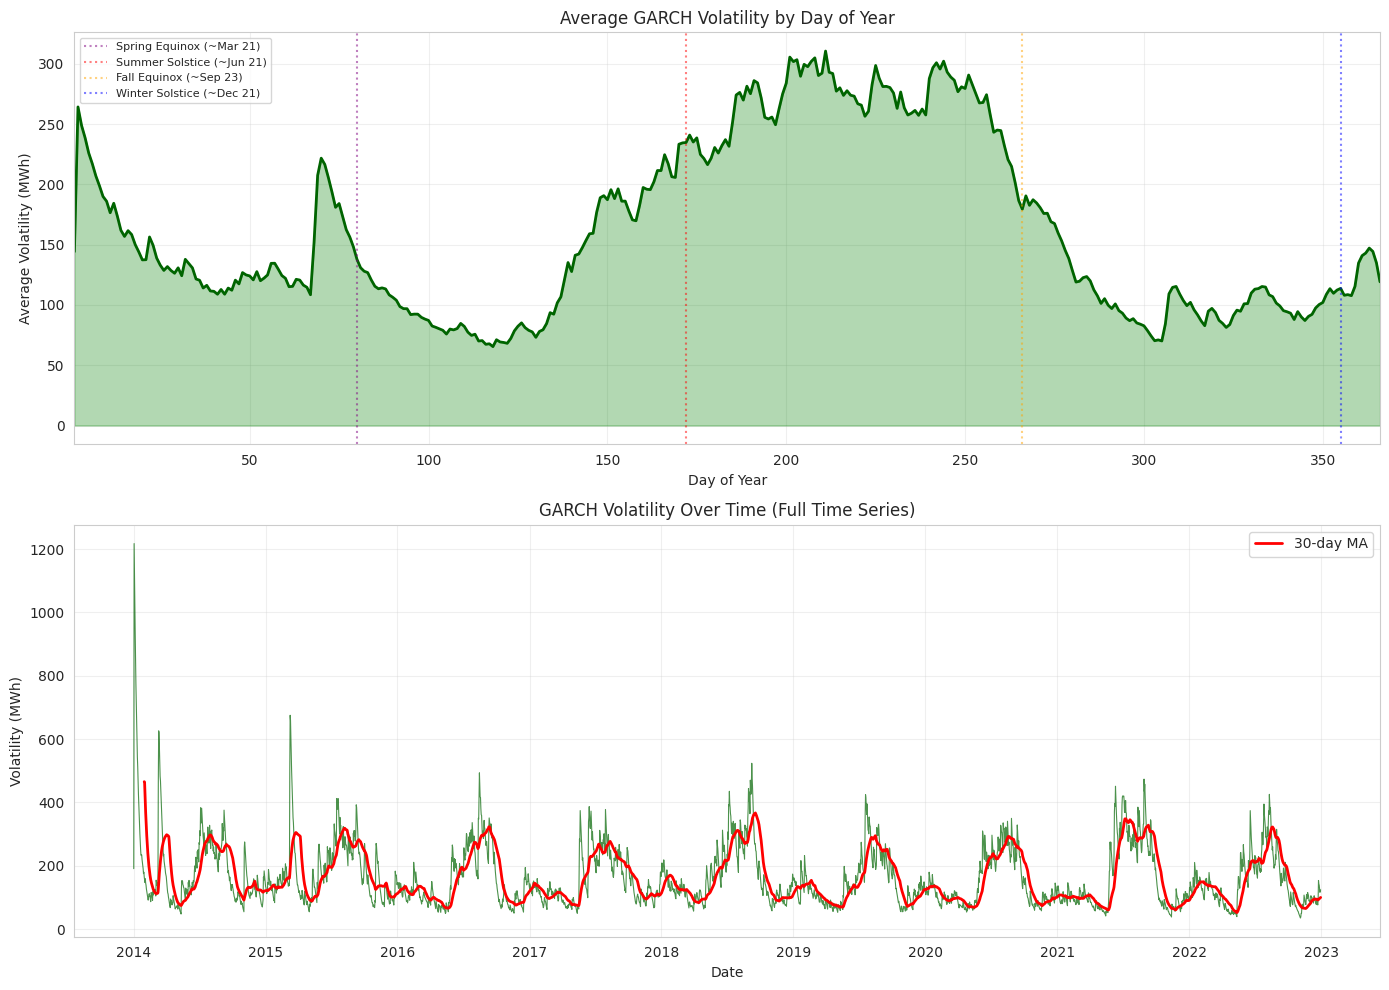


Most volatile days of year (top 10):
date
211    310.711262
201    305.699304
208    305.072288
203    303.524257
244    302.328000
207    302.104682
202    301.960593
242    301.016229
205    299.695322
225    298.741160
dtype: float64

Least volatile days of year (bottom 10):
date
118    65.467525
116    67.389458
117    67.824621
122    68.216884
121    68.900402
120    69.338886
114    70.112770
305    70.172496
303    70.350386
115    70.457457
dtype: float64


In [25]:
# Compare volatility patterns by season
volatility_by_doy = pd.Series(
    boston_garch_fit['volatility'], 
    index=boston_garch_fit['index']
).groupby(lambda x: x.day_of_year).mean()

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 10))

# Volatility by day of year
axes[0].plot(volatility_by_doy.index, volatility_by_doy.values, 
             color='darkgreen', lw=2)
axes[0].fill_between(volatility_by_doy.index, 0, volatility_by_doy.values, 
                      alpha=0.3, color='green')
axes[0].set_xlabel('Day of Year')
axes[0].set_ylabel('Average Volatility (MWh)')
axes[0].set_title('Average GARCH Volatility by Day of Year')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(1, 366)

# Mark seasons
axes[0].axvline(80, color='purple', linestyle=':', alpha=0.5, label='Spring Equinox (~Mar 21)')
axes[0].axvline(172, color='red', linestyle=':', alpha=0.5, label='Summer Solstice (~Jun 21)')
axes[0].axvline(266, color='orange', linestyle=':', alpha=0.5, label='Fall Equinox (~Sep 23)')
axes[0].axvline(355, color='blue', linestyle=':', alpha=0.5, label='Winter Solstice (~Dec 21)')
axes[0].legend(fontsize=8)

# Volatility over time (full time series)
axes[1].plot(boston_garch_fit['index'], boston_garch_fit['volatility'], 
             color='darkgreen', lw=0.8, alpha=0.7)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Volatility (MWh)')
axes[1].set_title('GARCH Volatility Over Time (Full Time Series)')
axes[1].grid(True, alpha=0.3)

# Add 30-day moving average
rolling_vol = pd.Series(
    boston_garch_fit['volatility'], 
    index=boston_garch_fit['index']
).rolling(30).mean()
axes[1].plot(rolling_vol.index, rolling_vol.values, 
             color='red', lw=2, label='30-day MA')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/Boston/volatility_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

# Find most/least volatile periods
print("\nMost volatile days of year (top 10):")
print(volatility_by_doy.nlargest(10))
print("\nLeast volatile days of year (bottom 10):")
print(volatility_by_doy.nsmallest(10))

## Apply Seasonal + GARCH Model to All Regions

Fit the combined model to all 6 regions and compare volatility characteristics

In [26]:
# # Fit seasonal + GARCH models to all regions and compare using AIC/BIC
# regions_dict = {
#     'Boston': df_boston['avg_load'],
#     'NewYork': df_ny['avg_load'],
#     # 'Houston': df_houston['avg_load'],
#     'Chicago': df_chicago['avg_load'],
#     # 'Dallas': df_dallas['avg_load'],
#     'Minneapolis': df_minneapolis['avg_load'],
# }

# print("Fitting models for all regions...")
# print("This may take a few minutes...\n")

# # Fit models with 3 and 6 harmonics for all regions
# all_regions_comparison = fit_all_regions(
#     regions_dict, 
#     harmonics_list=[3, 6],
#     ar_order_list=[0, 1, 2, 3],
#     ma_order_list=[0, 1, 2, 3],
#     garch_p_list = [1,2,3],
#     garch_q_list = [1,2,3]
# )

# print("\n" + "=" * 100)
# print("MODEL COMPARISON - ALL REGIONS (3H vs 6H + GARCH)")
# print("=" * 100)
# print(all_regions_comparison.to_string(index=False))

# print("\n" + "=" * 100)
# print("BEST MODELS BY REGION")
# print("=" * 100)

# # For each region, determine the best model by AIC and BIC
# for region in regions_dict.keys():
#     region_data = all_regions_comparison[all_regions_comparison['Region'] == region]
#     best_aic = region_data.loc[region_data['AIC'].idxmin(), 'Model']
#     best_bic = region_data.loc[region_data['BIC'].idxmin(), 'Model']
    
#     print(f"{region:<15} | Best by AIC: {best_aic:<20} | Best by BIC: {best_bic:<20}")

# print("=" * 100)

# # Save results to CSV
# output_path = '../data/processed/all_regions_model_comparison.csv'
# all_regions_comparison.to_csv(output_path, index=False)
# print(f"\n✓ Results saved to: {output_path}")


In [27]:
df_data = {
    'Boston': df_boston,
    'NewYork': df_ny,
    # 'Houston': df_houston,
    'Chicago': df_chicago,
    # 'Dallas': df_dallas,
    'Minneapolis': df_minneapolis,
}

In [28]:
df_result = {}

for region_name, load_data in df_data.items():
    print(f"  Fitting {region_name}...")
    if region_name == 'Boston':
        df_result[region_name] = fit_seasonal_garch_model(load_data['avg_load'], n_harmonics=3, ar_order=0, ma_order=2, garch_p=1, garch_q=2)
    elif region_name == 'NewYork':
        df_result[region_name] = fit_seasonal_garch_model(load_data['avg_load'], n_harmonics=3, ar_order=1, ma_order=3, garch_p=1, garch_q=3)
    elif region_name == 'Chicago':
        df_result[region_name] = fit_seasonal_garch_model(load_data['avg_load'], n_harmonics=3, ar_order=1, ma_order=3, garch_p=2, garch_q=3)
    elif region_name == 'Minneapolis':
        df_result[region_name] = fit_seasonal_garch_model(load_data['avg_load'], n_harmonics=3, ar_order=1, ma_order=3, garch_p=2, garch_q=3)
    
    

  Fitting Boston...


/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/workspaces/Financial-Engineering-Project/notebooks/seasonal_models.py:167: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'constant': armax_result.params[0],


  Fitting NewYork...


/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/workspaces/Financial-Engineering-Project/notebooks/seasonal_models.py:167: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'constant': armax_result.params[0],
/workspaces/Financial-Engineering-Project/notebooks/seasonal_models.py:167: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (co

  Fitting Chicago...


/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/workspaces/Financial-Engineering-Project/notebooks/seasonal_models.py:167: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'constant': armax_result.params[0],
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/l

  Fitting Minneapolis...


/workspaces/Financial-Engineering-Project/notebooks/seasonal_models.py:167: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'constant': armax_result.params[0],


In [29]:
# Build a DataFrame of residuals, aligned by date
df_res = pd.DataFrame({
    station: pd.Series(df_result[station]["residuals"], index=df_result[station]["index"])
    for station in SET_TARGET_US_CITIES
})

# Optionally, drop rows with any missing values to ensure alignment
df_res = df_res.dropna()

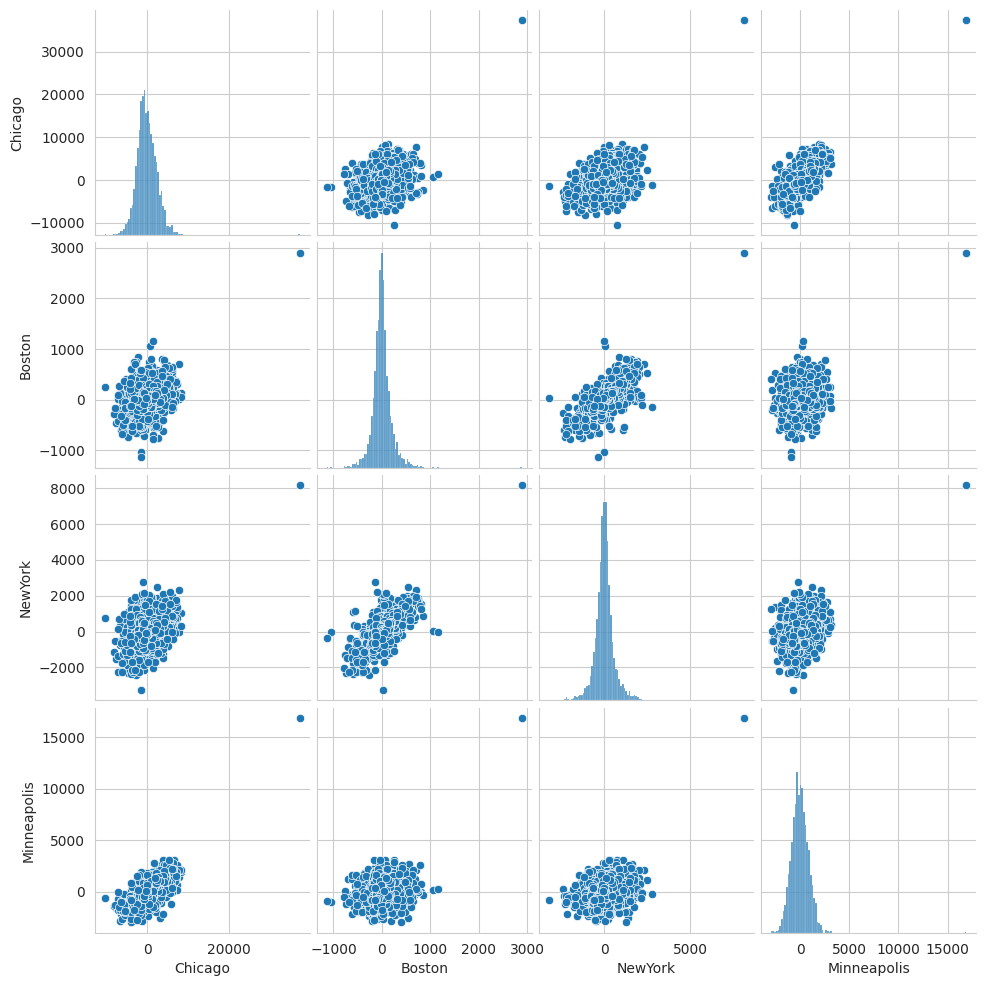

In [30]:
sns.pairplot(df_res)

Text(0.5, 1.0, "Kendall's tau, Residuals from 4 cities in the US")

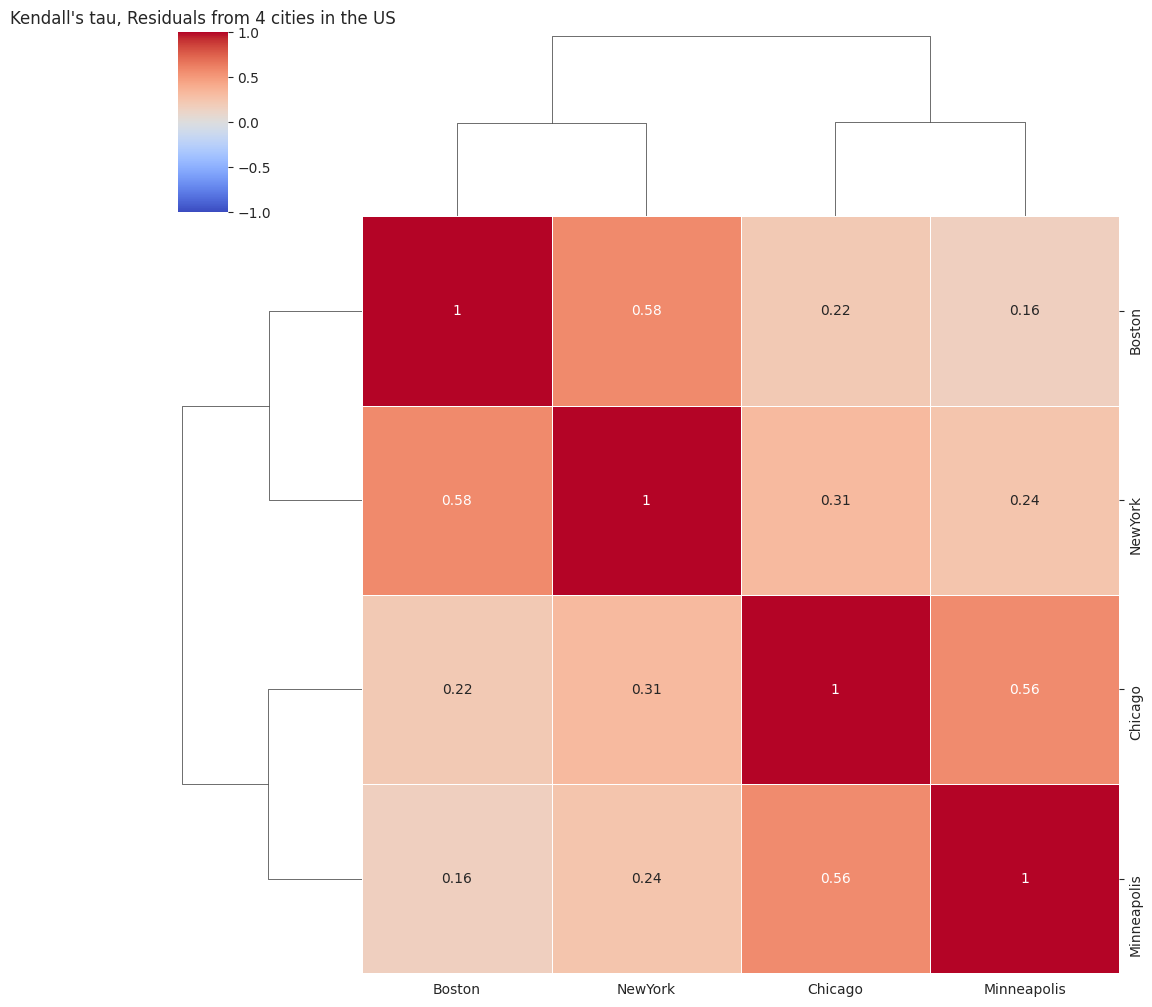

In [31]:
sns.clustermap(
    df_res.corr(method="kendall"),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    vmin=-1,
    vmax=1,
)
plt.title("Kendall's tau, Residuals from 4 cities in the US")

In [32]:
df_cdd_load_res = df_res[df_res.index.month.isin(MONTH_CDD)]

df_hdd_load_res = df_res[df_res.index.month.isin(MONTH_HDD)]

Text(0.5, 1.0, "Kendall's tau, Residuals from 4 cities in the US")

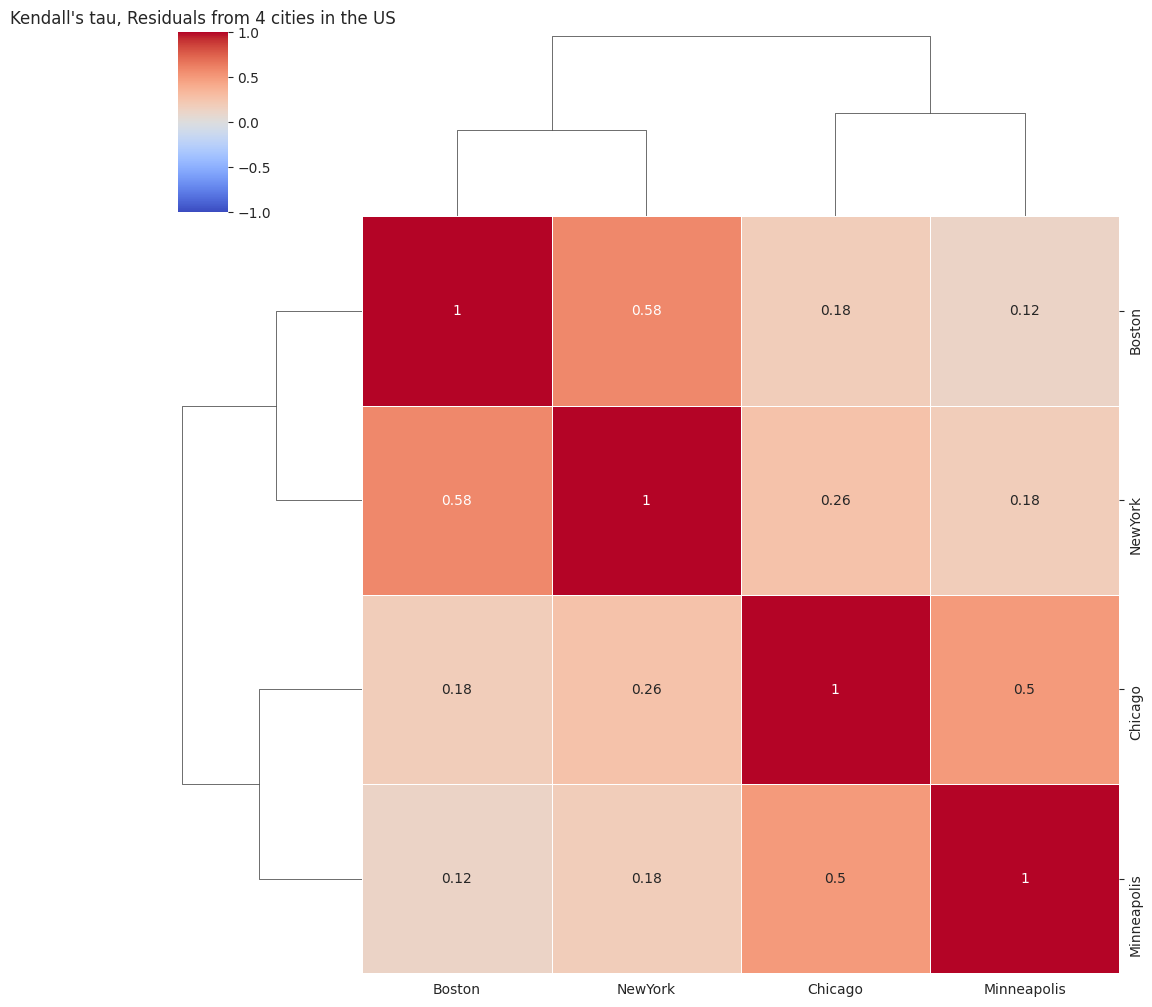

In [33]:
sns.clustermap(
    df_cdd_load_res.corr(method="kendall"),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    vmin=-1,
    vmax=1,
)
plt.title("Kendall's tau, Residuals from 4 cities in the US")

Text(0.5, 1.0, "Kendall's tau, Residuals from 4 cities in the US")

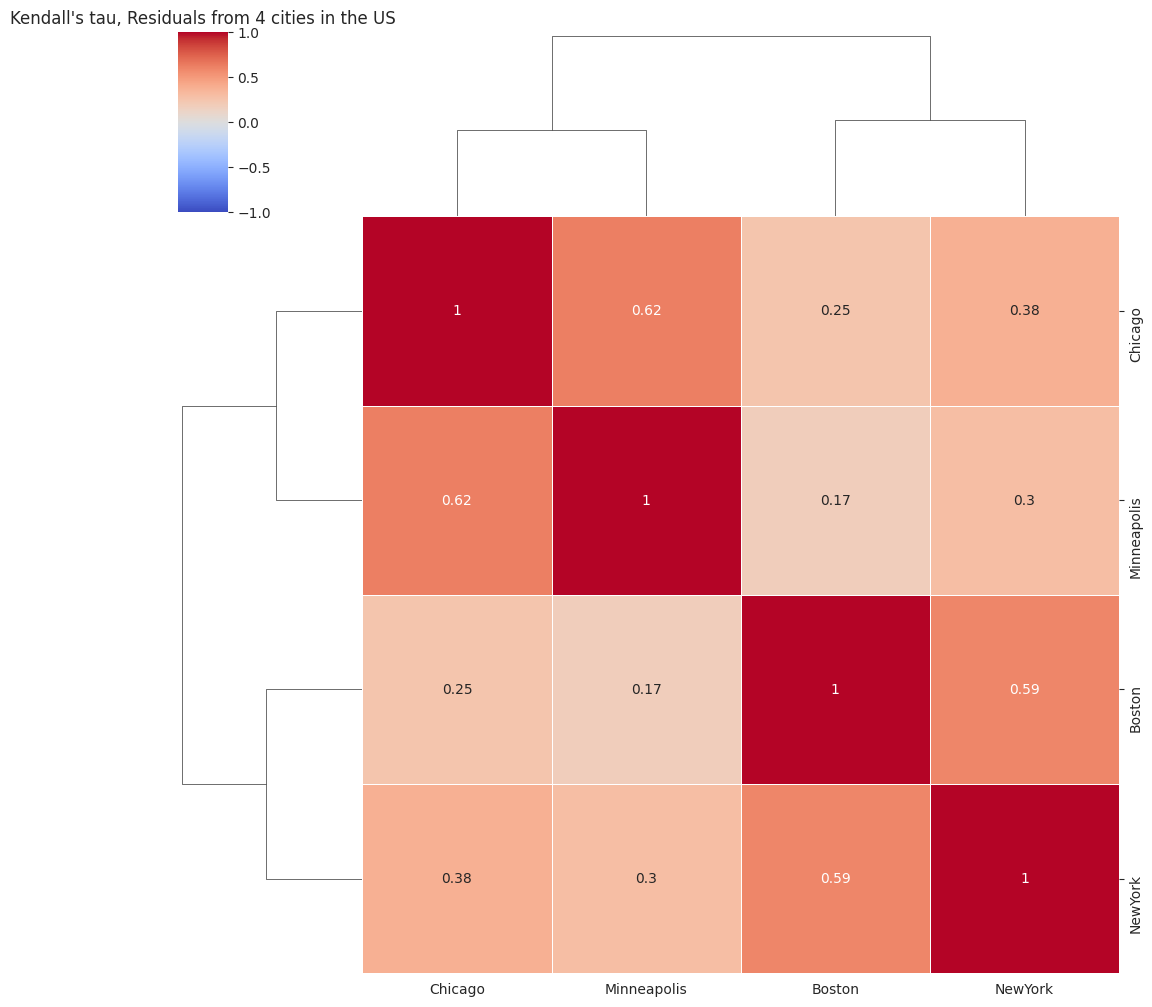

In [34]:
sns.clustermap(
    df_hdd_load_res.corr(method="kendall"),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    vmin=-1,
    vmax=1,
)
plt.title("Kendall's tau, Residuals from 4 cities in the US")

In [35]:
# Ensure torch is available
import torch

dct_evi_load_res_right = {}
for station in SET_TARGET_US_CITIES:
    tmp_vec = df_res[station].values
    # ! right tail
    tmp_vec = tmp_vec[tmp_vec > 0]
    dct_evi_load_res_right[station] = {
        "hill": unibm.benchmark.est_extreme_value_index_hill(torch.tensor(tmp_vec)),
        "schultze_steinebach": unibm.benchmark.est_extreme_value_index_schultze_steinebach(
            torch.tensor(tmp_vec)
        ),
        "smith": unibm.benchmark.est_extreme_value_index_smith(torch.tensor(tmp_vec)),
        "meerschaert_scheffler": unibm.benchmark.est_extreme_value_index_meerschaert_scheffler(
            torch.tensor(tmp_vec)
        ),
        "genextreme": genextreme.fit(tmp_vec, floc=0)[0].item(),
        "genpareto": genpareto.fit(tmp_vec, floc=0)[0].item(),
        "pareto": pareto.fit(tmp_vec, floc=0)[0].item(),
        # ! is_frechet=False
        "mpmr_wls": unibm.est_extreme_value_index(tmp_vec, is_frechet=False)[
            "slope_emr"
        ],
    }
    
dct_evi_load_res_left = {}

for station in SET_TARGET_US_CITIES:
    temp_vec = df_res[station].values
    # ! left tail
    temp_vec = -temp_vec[temp_vec < 0]
    dct_evi_load_res_left[station] = {
        "hill": unibm.benchmark.est_extreme_value_index_hill(torch.tensor(temp_vec)),
        "schultze_steinebach": unibm.benchmark.est_extreme_value_index_schultze_steinebach(
            torch.tensor(temp_vec)
        ),
        "smith": unibm.benchmark.est_extreme_value_index_smith(torch.tensor(temp_vec)),
        "meerschaert_scheffler": unibm.benchmark.est_extreme_value_index_meerschaert_scheffler(
            torch.tensor(temp_vec)
        ),
        "genextreme": genextreme.fit(temp_vec, floc=0)[0].item(),
        "genpareto": genpareto.fit(temp_vec, floc=0)[0].item(),
        "pareto": pareto.fit(temp_vec, floc=0)[0].item(),
        # ! is_frechet=False
        "mpmr_wls": unibm.est_extreme_value_index(temp_vec, is_frechet=False)[
            "slope_emr"
        ],
    }


In [46]:
df_evi_res_right = pd.DataFrame(dct_evi_load_res_right).head(7)
df_evi_res_right[df_evi_res_right < 0] = np.abs(df_evi_res_right[df_evi_res_right < 0])
df_evi_res_right[np.isinf(df_evi_res_right)] = np.nan
display(df_evi_res_right)
df_evi_res_right.median(axis=0)

,Chicago,Boston,NewYork,Minneapolis
hill,1.760040,1.347998,1.424639,0.856108
schultze_steinebach,1.654961,0.966652,1.277075,1.405157
smith,0.219614,0.292389,0.268769,0.230380
meerschaert_scheffler,1.524593,1.188314,1.327842,1.383301
genextreme,0.009458,0.218611,0.221656,0.020140
genpareto,0.018081,0.097884,0.099438,0.003226
pareto,0.127228,0.123904,0.163118,0.138445


Chicago        0.219614
Boston         0.292389
NewYork        0.268769
Minneapolis    0.230380
dtype: float64

In [37]:
df_evi_res_left = pd.DataFrame(dct_evi_load_res_left).head(7)
df_evi_res_left[df_evi_res_left < 0] = np.abs(df_evi_res_left[df_evi_res_left < 0])
df_evi_res_left[np.isinf(df_evi_res_left)] = np.nan
display(df_evi_res_left)
df_evi_res_left.median(axis=0)

,Chicago,Boston,NewYork,Minneapolis
hill,0.085400,0.471843,0.767680,1.088213
schultze_steinebach,1.701873,1.011797,1.324854,1.482063
smith,0.188749,0.281582,0.301146,0.158966
meerschaert_scheffler,1.461953,1.146748,1.298204,1.335615
genextreme,0.117006,0.107369,0.122881,0.156148
genpareto,0.188506,0.004509,0.007202,0.258985
pareto,0.141069,0.156660,0.114213,0.156794


Chicago        0.188506
Boston         0.281582
NewYork        0.301146
Minneapolis    0.258985
dtype: float64

In [38]:
def ferreira_tail_dep_coeff(x: torch.Tensor, y: torch.Tensor) -> float:
    """pairwise tail dependence coefficient (λ) estimator, max of rotation 0, 90, 180, 270
    x and y are both of shape (n, 1) inside (0, 1)
    symmetric for (x,y), (y,1-x), (1-x,1-y), (1-y,x), (y,x), (1-x,y), (1-y,1-x), (x,1-y)
    Ferreira, M.S., 2013. Nonparametric estimation of the tail-dependence coefficient;
    """
    x1 = 1 - x
    y1 = 1 - y
    return (
        3
        - (
            1
            - torch.as_tensor(
                [
                    torch.max(x, y).mean(),
                    torch.max(y, x1).mean(),
                    torch.max(x1, y1).mean(),
                    torch.max(y1, x).mean(),
                ]
            )
            .clamp(0.5, 0.6666666666666666)
            .min()
        ).reciprocal()
    ).item()

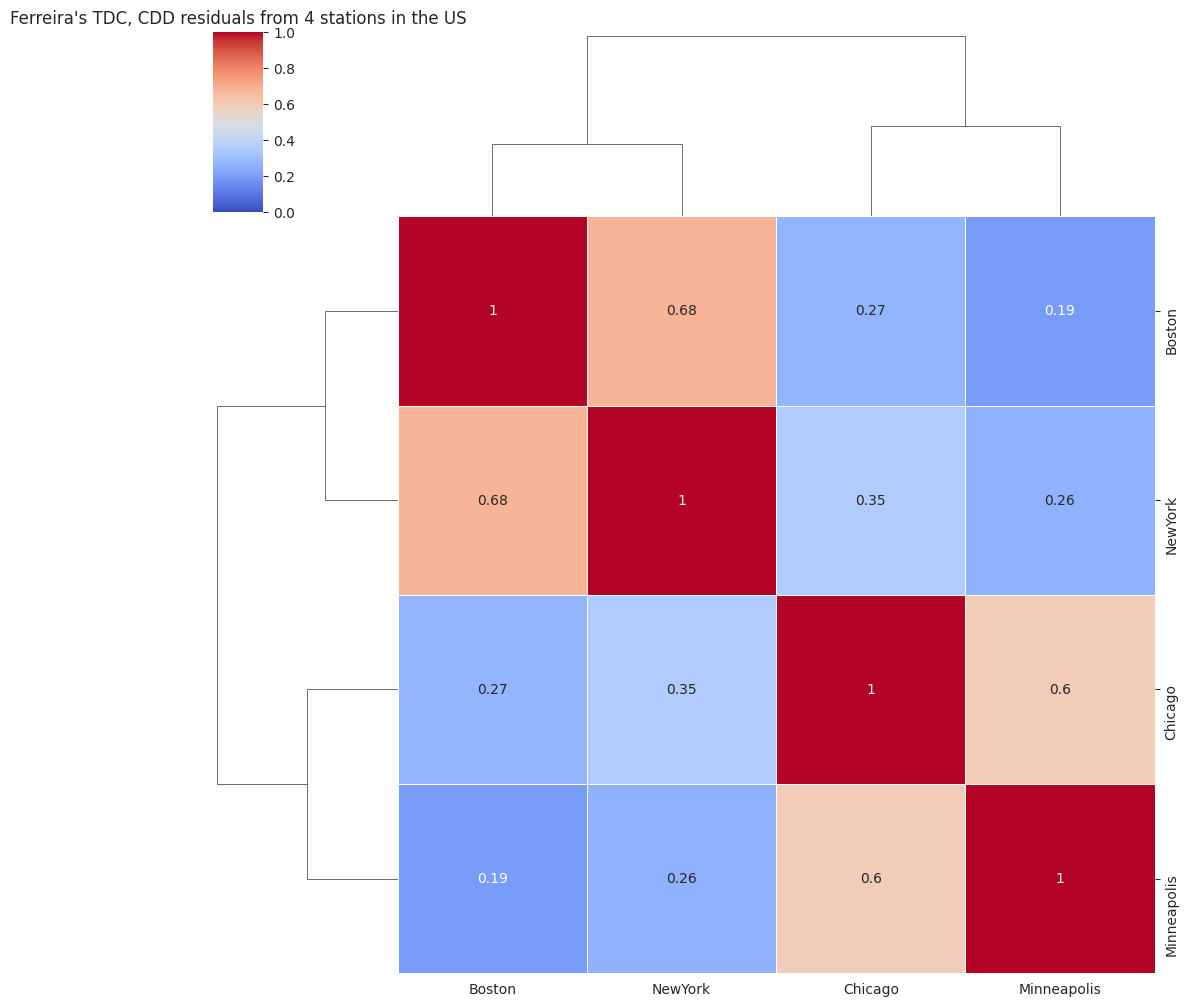

In [39]:
df_cdd_load_cop = df_cdd_load_res.apply(lambda vec: unibm.cdf_func_kernel(vec)(vec))
df_tdc_load_cdd_res = df_cdd_load_cop.corr(
    method=lambda x, y: ferreira_tail_dep_coeff(torch.tensor(x), torch.tensor(y))
)
g = sns.clustermap(
    df_tdc_load_cdd_res,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    vmin=0,
    vmax=1,
)
plt.title("Ferreira's TDC, CDD residuals from 4 stations in the US")

plt.savefig("Ferreira_TDC_CDD_residuals.svg", format='svg')

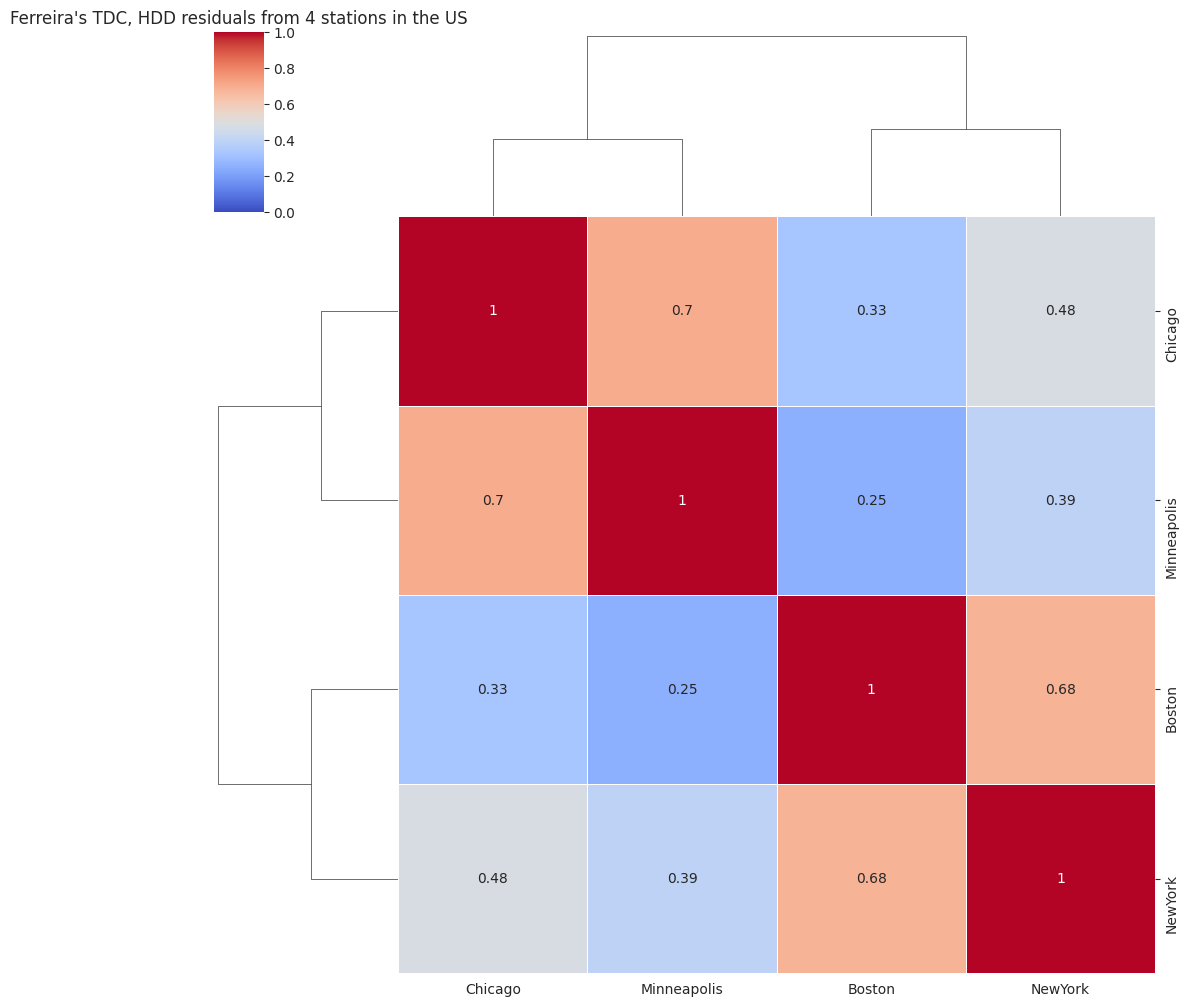

In [40]:
df_hdd_load_cop = df_hdd_load_res.apply(lambda vec: unibm.cdf_func_kernel(vec)(vec))
df_tdc_load_hdd_res = df_hdd_load_cop.corr(
    method=lambda x, y: ferreira_tail_dep_coeff(torch.tensor(x), torch.tensor(y))
)
g = sns.clustermap(
    df_tdc_load_hdd_res,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    vmin=0,
    vmax=1,
)
plt.title("Ferreira's TDC, HDD residuals from 4 stations in the US")

plt.savefig("Ferreira_TDC_HDD_residuals.svg", format='svg')

In [41]:
import pickle
# Save all relevant data to pickle files
with open('../data/processed/all_analysis_data.pkl', 'wb') as f:
    pickle.dump({
        'df_boston': df_boston,
        'df_ny': df_ny,
        # 'df_houston': df_houston,
        'df_chicago': df_chicago,
        # 'df_dallas': df_dallas,
        'df_minneapolis': df_minneapolis,
        'df_res': df_res,
        'df_cdd_load_res': df_cdd_load_res,
        'df_hdd_load_res': df_hdd_load_res,
        'df_result': df_result,
        'df_tdc_load_cdd_res': df_tdc_load_cdd_res,
        'df_tdc_load_hdd_res': df_tdc_load_hdd_res,
        'dct_evi_load_res_right': dct_evi_load_res_right,
        'dct_evi_load_res_left': dct_evi_load_res_left,
        'df_evi_res_right': df_evi_res_right,
        'df_evi_res_left': df_evi_res_left,
    }, f)

print("✓ All data saved to '../data/processed/all_analysis_data.pkl'")


✓ All data saved to '../data/processed/all_analysis_data.pkl'


## Extreme Value Theory (EVT) Analysis for Load Residuals

Analyzing the tail behavior of load residuals using Extreme Value Index (EVI) estimation.
Similar to the temperature analysis, we estimate the EVI for both left and right tails.

In [45]:
# Prepare residuals for EVT analysis
# Extract residuals from the fitted GARCH models

# Create a dictionary to store load residuals
load_residuals = {}

# For Boston (using the fitted model from earlier)
if 'results_boston' in locals():
    load_residuals['Boston'] = results_boston['residuals']
else:
    # If not fitted earlier, fit now
    results_boston = fit_seasonal_garch_model(
        srs_boston, 
        n_harmonics=3, 
        ar_order=1, 
        ma_order=1, 
        include_dayofweek=True
    )
    load_residuals['Boston'] = results_boston['residuals']

# For New York
if 'results_ny' in locals():
    load_residuals['NewYork'] = results_ny['residuals']
else:
    results_ny = fit_seasonal_garch_model(
        srs_ny, 
        n_harmonics=3, 
        ar_order=1, 
        ma_order=1, 
        include_dayofweek=True
    )
    load_residuals['NewYork'] = results_ny['residuals']

# For Chicago (if available)
if 'srs_chicago' in locals() and 'results_chicago' in locals():
    load_residuals['Chicago'] = results_chicago['residuals']

# For Minneapolis (if available)
if 'srs_minneapolis' in locals() and 'results_minneapolis' in locals():
    load_residuals['Minneapolis'] = results_minneapolis['residuals']

print(f"✓ Prepared residuals for {len(load_residuals)} regions")

NameError: name 'srs_boston' is not defined

In [ ]:
# Calculate Extreme Value Index (EVI) for both tails for each region

evi_results_load_left = {}
evi_results_load_right = {}

for region_name, residuals in load_residuals.items():
    print(f"\n{'='*60}")
    print(f"Processing {region_name} Load Residuals")
    print(f"{'='*60}")
    
    # Remove NaN values
    clean_residuals = residuals.dropna().values
    
    # Left tail (negative extremes - low load anomalies)
    # For left tail, we work with -residuals (convert to positive)
    left_tail_data = -clean_residuals[clean_residuals < 0]
    if len(left_tail_data) > 100:
        evi_left = unibm.est_extreme_value_index(
            left_tail_data,
            delta=0.1,
            is_frechet=True,
            is_weighted=True,
            is_retn_vec=True
        )
        evi_results_load_left[region_name] = evi_left
        print(f"  Left Tail EVI:  {evi_left.get('slope_emr', np.nan):.4f}")
    
    # Right tail (positive extremes - high load anomalies)
    right_tail_data = clean_residuals[clean_residuals > 0]
    if len(right_tail_data) > 100:
        evi_right = unibm.est_extreme_value_index(
            right_tail_data,
            delta=0.1,
            is_frechet=True,
            is_weighted=True,
            is_retn_vec=True
        )
        evi_results_load_right[region_name] = evi_right
        print(f"  Right Tail EVI: {evi_right.get('slope_emr', np.nan):.4f}")

print(f"\n✓ Completed EVI estimation for {len(load_residuals)} regions")

In [ ]:
# Visualize EVI results for left tail

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (region_name, evi_result) in enumerate(evi_results_load_left.items()):
    if idx < 4:  # Max 4 plots
        ax = axes[idx]
        
        # Extract data for plotting
        if 'vec_l_size' in evi_result and 'vec_emr' in evi_result:
            vec_l_size = evi_result['vec_l_size']
            vec_emr = evi_result['vec_emr']
            slope_emr = evi_result.get('slope_emr', np.nan)
            intercept_emr = evi_result.get('intercept_emr', np.nan)
            
            # Plot scatter
            ax.scatter(vec_l_size, vec_emr, alpha=0.5, s=20, label='Data')
            
            # Plot fitted line
            if not np.isnan(slope_emr) and not np.isnan(intercept_emr):
                fitted_line = slope_emr * vec_l_size + intercept_emr
                ax.plot(vec_l_size, fitted_line, 'r-', linewidth=2, 
                       label=f'EVI = {slope_emr:.4f}')
            
            ax.set_xlabel('log(block size)')
            ax.set_ylabel('EMR')
            ax.set_title(f'{region_name} Load - Left Tail (Low Load Extremes)')
            ax.legend()
            ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/images/load_evi_left_tail.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Left tail EVI plots saved")

In [ ]:
# Visualize EVI results for right tail

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (region_name, evi_result) in enumerate(evi_results_load_right.items()):
    if idx < 4:  # Max 4 plots
        ax = axes[idx]
        
        # Extract data for plotting
        if 'vec_l_size' in evi_result and 'vec_emr' in evi_result:
            vec_l_size = evi_result['vec_l_size']
            vec_emr = evi_result['vec_emr']
            slope_emr = evi_result.get('slope_emr', np.nan)
            intercept_emr = evi_result.get('intercept_emr', np.nan)
            
            # Plot scatter
            ax.scatter(vec_l_size, vec_emr, alpha=0.5, s=20, label='Data')
            
            # Plot fitted line
            if not np.isnan(slope_emr) and not np.isnan(intercept_emr):
                fitted_line = slope_emr * vec_l_size + intercept_emr
                ax.plot(vec_l_size, fitted_line, 'r-', linewidth=2, 
                       label=f'EVI = {slope_emr:.4f}')
            
            ax.set_xlabel('log(block size)')
            ax.set_ylabel('EMR')
            ax.set_title(f'{region_name} Load - Right Tail (High Load Extremes)')
            ax.legend()
            ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/images/load_evi_right_tail.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Right tail EVI plots saved")

In [ ]:
# Save EVI results to CSV files

# Left tail results
left_tail_data = []
for region, result in evi_results_load_left.items():
    left_tail_data.append({
        'region': region,
        'tail': 'left',
        'evi_emr': result.get('slope_emr', np.nan),
        'evi_mpmr': result.get('slope_mpmr', np.nan),
        'intercept_emr': result.get('intercept_emr', np.nan),
        'intercept_mpmr': result.get('intercept_mpmr', np.nan),
        'size_min': result.get('size_min', np.nan),
        'size_max': result.get('size_max', np.nan)
    })

df_load_evi_left = pd.DataFrame(left_tail_data)
df_load_evi_left.to_csv('../data/processed/load_evi_left_tail.csv', index=False)
print("✓ Saved left tail EVI results")

# Right tail results
right_tail_data = []
for region, result in evi_results_load_right.items():
    right_tail_data.append({
        'region': region,
        'tail': 'right',
        'evi_emr': result.get('slope_emr', np.nan),
        'evi_mpmr': result.get('slope_mpmr', np.nan),
        'intercept_emr': result.get('intercept_emr', np.nan),
        'intercept_mpmr': result.get('intercept_mpmr', np.nan),
        'size_min': result.get('size_min', np.nan),
        'size_max': result.get('size_max', np.nan)
    })

df_load_evi_right = pd.DataFrame(right_tail_data)
df_load_evi_right.to_csv('../data/processed/load_evi_right_tail.csv', index=False)
print("✓ Saved right tail EVI results")

# Display summary
print("\n" + "="*60)
print("LOAD EVI SUMMARY")
print("="*60)
print("\nLeft Tail (Low Load Extremes):")
print(df_load_evi_left[['region', 'evi_emr']].to_string(index=False))
print("\nRight Tail (High Load Extremes):")
print(df_load_evi_right[['region', 'evi_emr']].to_string(index=False))

### Interpretation of EVI Results

**Extreme Value Index (ξ)**:
- ξ > 0: Heavy-tailed distribution (Fréchet domain) - extremes can be very large
- ξ = 0: Exponential-type tail (Gumbel domain) - moderate tail behavior
- ξ < 0: Bounded distribution (Weibull domain) - extremes have upper limit

**For Load Residuals**:
- **Left Tail** (negative residuals): Represents unexpectedly low electricity demand
  - Higher ξ indicates more extreme low-demand events
  - Important for generation planning and reserve requirements
  
- **Right Tail** (positive residuals): Represents unexpectedly high electricity demand
  - Higher ξ indicates more extreme high-demand spikes
  - Critical for grid stability and capacity planning
  
**Practical Implications**:
1. **Risk Management**: Higher EVI values suggest greater potential for extreme deviations
2. **Capacity Planning**: Right-tail extremes inform peak capacity requirements
3. **Hedging Strategies**: Tail behavior affects pricing of load-following contracts
4. **Regional Differences**: Compare EVI across regions to identify vulnerability patterns